# Анализ взаимодействия между музыкальными элементами и эмоциями

**Датасет:** PANDA / TAFFC — 900 аудиоклипов (~30 сек), размечены по модели Рассела

| Папка | Индекс | Эмоция |
|-------|--------|--------|
| Q1    | 0      | Happy — радость (+Valence, +Arousal) |
| Q2    | 1      | Angry — гнев/напряжение (−Valence, +Arousal) |
| Q3    | 2      | Sad — грусть (−Valence, −Arousal) |
| Q4    | 3      | Relaxed — спокойствие (+Valence, −Arousal) |

**Цель:** Исследовать, как музыкальные характеристики (темп, тональность, громкость) влияют на восприятие эмоций.
**Задачи:**
1. Извлечь признаки из аудио: темп (BPM), среднюю громкость, частотный спектр.
2. Построить регрессионную модель (например, Random Forest) для оценки влияния признаков на эмоции.
3. Использовать SHAP для интерпретации важности признаков.
4. Визуализировать зависимости (например, график зависимости громкости от эмоции "гнев").

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import librosa
import shap

from pathlib import Path
from tqdm import tqdm

from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [2]:
DATA_ROOT = Path('../data')

EMOTION_MAP = {
    'Q1': {'label': 'happy', 'index': 0, 'valence': +1, 'arousal': +1, 'color': '#F4D03F'},
    'Q2': {'label': 'angry', 'index': 1, 'valence': -1, 'arousal': +1, 'color': '#E74C3C'},
    'Q3': {'label': 'sad', 'index': 2, 'valence': -1, 'arousal': -1, 'color': '#5DADE2'},
    'Q4': {'label': 'relaxed', 'index': 3, 'valence': +1, 'arousal': -1, 'color': '#58D68D'},
}

COLORS = [EMOTION_MAP[q]['color'] for q in ['Q1', 'Q2', 'Q3', 'Q4']]
LABELS = [EMOTION_MAP[q]['label'] for q in ['Q1', 'Q2', 'Q3', 'Q4']]

total = 0
for folder, info in EMOTION_MAP.items():
    path = DATA_ROOT / folder
    if path.exists():
        files = list(path.glob('*.mp3')) + list(path.glob('*.wav'))
        count = len(files)
        total += count
        print(f'{folder} ({info["label"]}): {count:3d} файлов')
    else:
        print(f'{folder}: папка не найдена')
print(f'Итого: {total} файлов')

Q1 (happy): 225 файлов
Q2 (angry): 225 файлов
Q3 (sad): 225 файлов
Q4 (relaxed): 225 файлов
Итого: 900 файлов


## Извлечение признаков из аудио

Извлекаем следующие признаки:
- **Tempo (BPM)** - темп
- **Loudness (RMS)** - средняя громкость
- **Spectral Centroid** - центроид спектра ("яркость" звука)
- **Spectral Rolloff** - граница 85% энергии спектра
- **Spectral Bandwidth** - ширина спектра
- **Zero-Crossing Rate (ZCR)** - скорость пересечения нуля
- **MFCC 1–13** - мел-частотные кепстральные коэффициенты
- **Chroma** - хроматические признаки (тональность)
- **Valence / Arousal** - числовые координаты модели Рассела

In [3]:
def extract_features(file_path: str, sr: int = 22050, duration: float = 30.0) -> dict | None:
    """
    Извлекает музыкальные признаки из аудиофайла

    Args:
        file_path: путь к аудиофайлу (.mp3 или .wav)
        sr: частота дискретизации (по умолчанию 22050 Гц)
        duration: длительность  фрагмента в секундах

    Returns:
        dict с признаками или None при ошибке
    """
    try:
        y, sr = librosa.load(file_path, sr=sr, duration=duration, mono=True)

        features = {}

        # Темп
        tempo, _ = librosa.beat.beat_track(y=y, sr=sr)
        features['tempo'] = float(np.asarray(tempo).flat[0])

        # Громкость (RMS)
        rms = librosa.feature.rms(y=y)
        features['loudness_mean'] = float(np.mean(rms))
        features['loudness_std'] = float(np.std(rms))

        # Спектральные признаки
        spec_centroid  = librosa.feature.spectral_centroid(y=y, sr=sr)
        spec_rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr, roll_percent=0.85)
        spec_bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr)

        features['spectral_centroid_mean'] = float(np.mean(spec_centroid))
        features['spectral_rolloff_mean'] = float(np.mean(spec_rolloff))
        features['spectral_bandwidth_mean'] = float(np.mean(spec_bandwidth))

        # Zero-Crossing Rate
        zcr = librosa.feature.zero_crossing_rate(y)
        features['zcr_mean'] = float(np.mean(zcr))

        # MFCC (13 коэффициентов)
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
        for i, coef in enumerate(mfcc, 1):
            features[f'MFCC_{i}'] = float(np.mean(coef))

        # Chroma (12 полутонов)
        chroma = librosa.feature.chroma_stft(y=y, sr=sr)
        features['chroma_mean'] = float(np.mean(chroma))
        features['chroma_std'] = float(np.std(chroma))

        return features

    except Exception as e:
        print(f'Ошибка при обработке {file_path}: {e}')
        return None

In [4]:
CACHE_FILE = Path('../data/features_cache.csv') # на случай, если уже была загрузка файлов, чтоб снова не загружать

if CACHE_FILE.exists():
    df = pd.read_csv(CACHE_FILE)
    print(f'Загружено {len(df)} строк, {len(df.columns)} столбцов')
else:
    records = []

    for folder, info in EMOTION_MAP.items():
        path = DATA_ROOT / folder
        if not path.exists():
            print(f'Папка {path} не найдена — пропускаем')
            continue

        files = sorted(list(path.glob('*.mp3')) + list(path.glob('*.wav')))
        print(f'\nОбрабатываем {folder} ({info["label"]}): {len(files)} файлов')

        for fp in tqdm(files, desc=f'{folder}', leave=False):
            feats = extract_features(str(fp))
            if feats is not None:
                feats['file'] = fp.name
                feats['folder'] = folder
                feats['emotion'] = info['label']
                feats['emotion_idx'] = info['index']
                feats['valence'] = info['valence']
                feats['arousal'] = info['arousal']
                records.append(feats)

    df = pd.DataFrame(records)
    df.to_csv(CACHE_FILE, index=False)
    print(f'\nПризнаки сохранены в {CACHE_FILE}')
    print(f'Итого: {len(df)} файлов обработано')

Загружено 900 строк, 28 столбцов


In [5]:
df.head(5)

,tempo,loudness_mean,loudness_std,spectral_centroid_mean,spectral_rolloff_mean,spectral_bandwidth_mean,zcr_mean,MFCC_1,MFCC_2,MFCC_3,...,MFCC_12,MFCC_13,chroma_mean,chroma_std,file,folder,emotion,emotion_idx,valence,arousal
0,99.384014,0.204127,0.073971,2146.940511,5213.201810,2685.679865,0.068459,-85.872467,93.539543,22.547556,...,-4.158273,-5.707183,0.378782,0.288813,MT0000040632.mp3,Q1,happy,0,1,1
1,129.199219,0.130548,0.043504,2736.586158,5603.332784,2575.917125,0.143797,-73.055061,76.041733,-4.589801,...,3.384572,-5.410607,0.369929,0.290237,MT0000082187.mp3,Q1,happy,0,1,1
2,161.499023,0.271291,0.091591,2715.342116,6037.113494,2830.498986,0.100305,-21.326622,74.553276,5.179873,...,0.224185,-3.908479,0.377025,0.299132,MT0000249842.mp3,Q1,happy,0,1,1
3,123.046875,0.173934,0.035406,1582.084074,3293.480085,2066.327765,0.069470,-90.921913,126.462753,1.253699,...,3.455256,-0.073436,0.296106,0.280895,MT0000364027.mp3,Q1,happy,0,1,1
4,92.285156,0.090475,0.040513,2102.834964,4383.640159,2184.293307,0.095860,-147.818329,106.715996,-14.053626,...,2.936568,-2.916559,0.347002,0.285603,MT0000392975.mp3,Q1,happy,0,1,1


## EDA

In [6]:
print('Распределение по эмоциям:')
print(df['emotion'].value_counts().to_string())

print('\nОписательная статистика ключевых признаков:')
df[['tempo', 'loudness_mean', 'spectral_centroid_mean', 'zcr_mean']].describe().round(3)

Распределение по эмоциям:
emotion
happy      225
angry      225
sad        225
relaxed    225

Описательная статистика ключевых признаков:


,tempo,loudness_mean,spectral_centroid_mean,zcr_mean
count,900.000,900.000,900.000,900.000
mean,120.302,0.144,2038.531,0.099
std,28.255,0.069,677.986,0.042
min,58.727,0.017,382.657,0.020
25%,99.384,0.093,1503.325,0.067
50%,117.454,0.132,2045.473,0.096
75%,135.999,0.190,2523.590,0.128
max,234.908,0.401,3633.572,0.250


Датасет содержит 900 аудиоклипов (по 225 на каждую эмоцию), классы полностью сбалансированы, смещения модели нет

- Темп: среднее ~120 BPM, диапазон 59–235. Охватывает как медленные (Sad/Relaxed), так и быстрые треки (Happy/Angry)
- Громкость: среднее 0.144, максимум 0.401 - большой разброс указывает на существенные различия в динамике между эмоциями.
- Спектральный центроид: ~2039 Гц в среднем, ожидаем, что у Happy и Angry значения выше, т.к. звук более "яркий"
- ZCR: среднее 0.099 - отражает шумность и ударные, важен для разделения Angry от спокойных классов

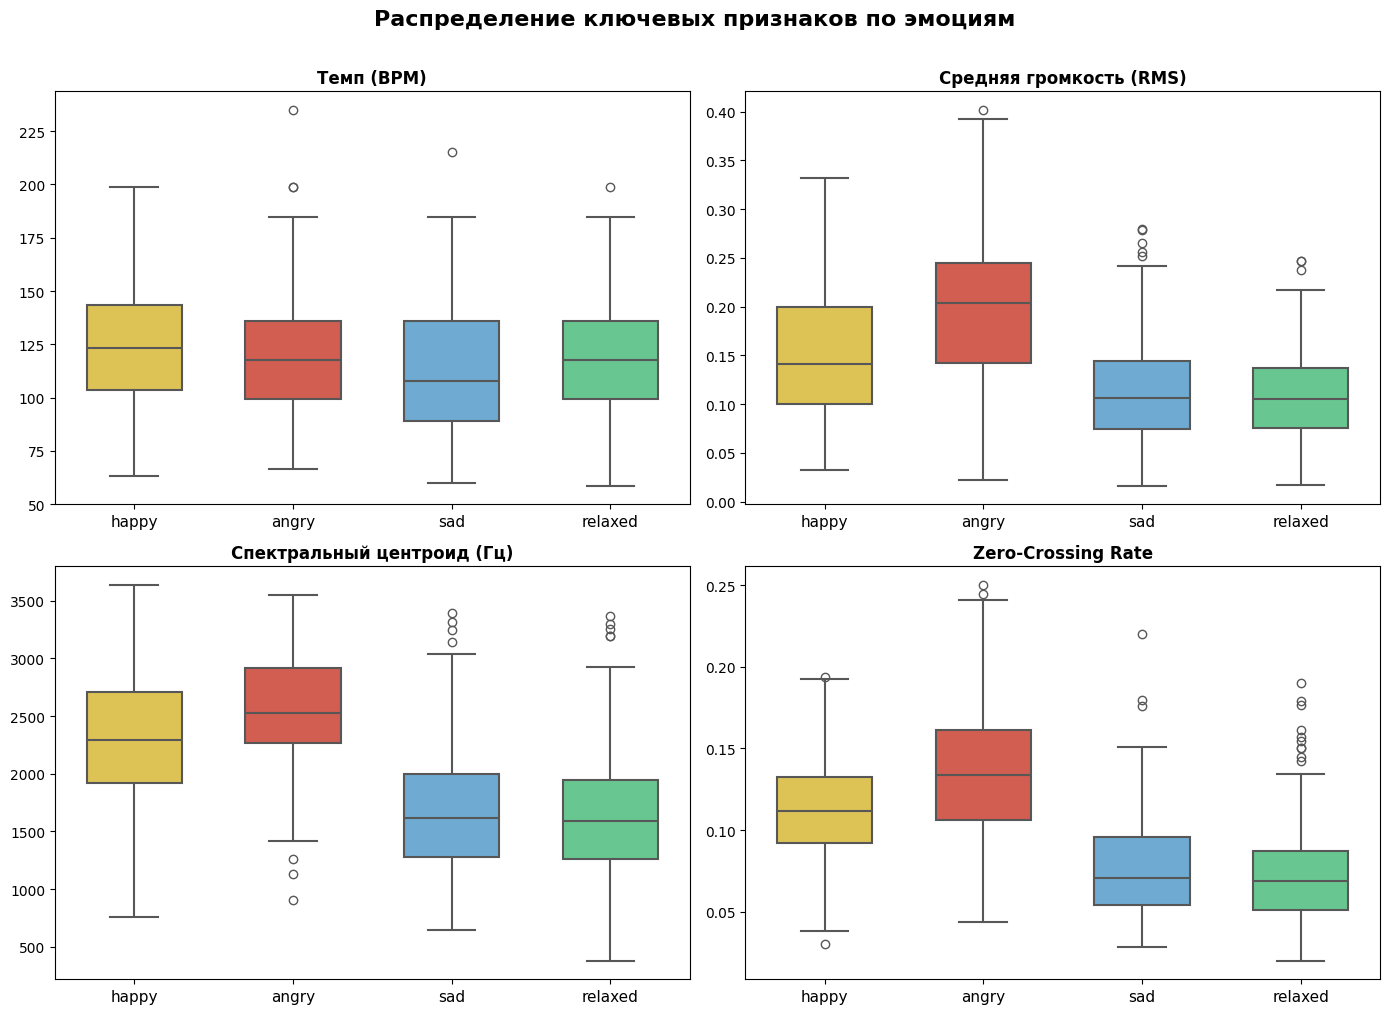

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Распределение ключевых признаков по эмоциям', fontsize=16, fontweight='bold', y=1.01)

features_to_plot = [
    ('tempo', 'Темп (BPM)'),
    ('loudness_mean', 'Средняя громкость (RMS)'),
    ('spectral_centroid_mean', 'Спектральный центроид (Гц)'),
    ('zcr_mean', 'Zero-Crossing Rate'),
]

emotion_order = ['happy', 'angry', 'sad', 'relaxed']
palette = {'happy': '#F4D03F', 'angry': '#E74C3C', 'sad': '#5DADE2', 'relaxed': '#58D68D'}

for ax, (feat, title) in zip(axes.flat, features_to_plot):
    sns.boxplot(data=df, x='emotion', y=feat, order=emotion_order, palette=palette, width=0.6, linewidth=1.5, ax=ax)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.tick_params(axis='x', labelsize=11)

plt.tight_layout()
plt.show()

- Темп: Happy, Angry и Relaxed имеют наиболее высокий медианный BPM (120-125 BPM). Sad заметно медленнее (105 BPM). Темп в одиночку эмоции не разделяет
- Громкость: Angry выделяется наибольшей медианной громкостью (0.2) и широким разбросом - агрессивная музыка динамически непредсказуема. Relaxed ялвяется самым тихим классом
- Спектральный центроид: Happy и Angry имеют более высокую "яркость". Sad и Relaxed не такие яркие, имеют более приглушённый тембр
- ZCR: Angry лидирует по ZCR, что отражает большое количество ударных и резких звуков. У Relaxed ZCR минимальный, характерный для плавных протяжных звуков

Sad и Relaxed в целом очень похожи между собой, разделять их по ключевым признакам довльно тяжело

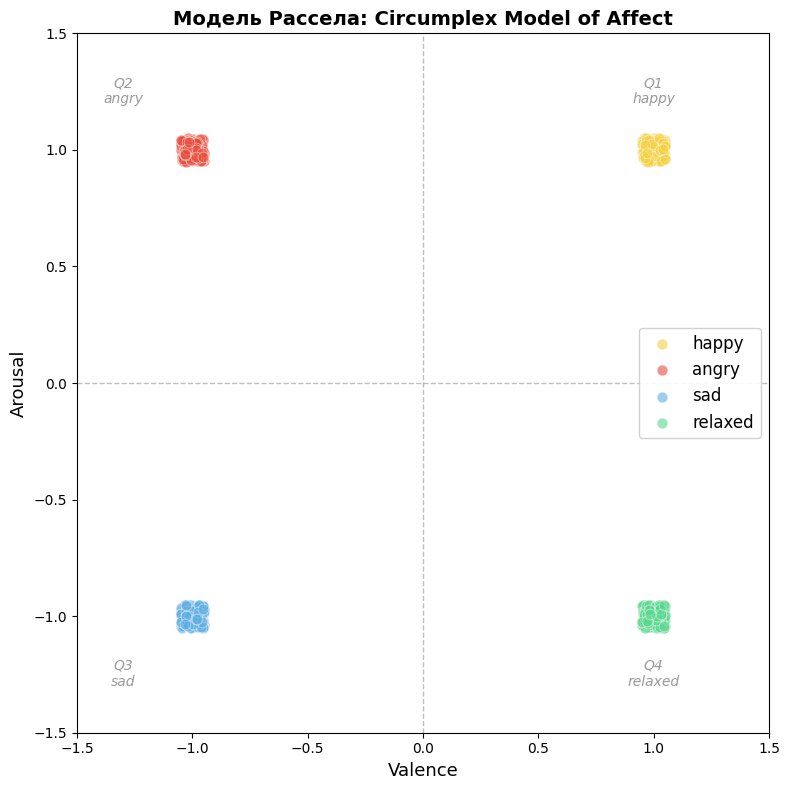

In [8]:
fig, ax = plt.subplots(figsize=(8, 8))

for folder, info in EMOTION_MAP.items():
    subset = df[df['folder'] == folder]
    # добавляем небольшой jitter для наглядности
    jitter = 0.05
    ax.scatter(
        subset['valence'] + np.random.uniform(-jitter, jitter, len(subset)),
        subset['arousal'] + np.random.uniform(-jitter, jitter, len(subset)),
        c=info['color'], label=f"{info['label']}",
        alpha=0.6, s=60, edgecolors='white', linewidths=0.5
    )

ax.axhline(0, color='gray', linewidth=1, linestyle='--', alpha=0.5)
ax.axvline(0, color='gray', linewidth=1, linestyle='--', alpha=0.5)
ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-1.5, 1.5)
ax.set_xlabel('Valence', fontsize=13)
ax.set_ylabel('Arousal', fontsize=13)
ax.set_title('Модель Рассела: Circumplex Model of Affect', fontsize=14, fontweight='bold')

for txt, xy in [('Q2\nangry', (-1.3, 1.2)), ('Q1\nhappy', (1.0, 1.2)),
                ('Q3\nsad', (-1.3, -1.3)), ('Q4\nrelaxed', (1.0, -1.3))]:
    ax.text(*xy, txt, fontsize=10, alpha=0.4, ha='center', style='italic')

ax.legend(fontsize=12, framealpha=0.9)
plt.tight_layout()
plt.show()

- Четыре квадранта чётко разделены по знаку Valence/Arousal согласно теоретической модели Расселла
- Happy (+V, +A) и Angry (−V, +A) - оба высокоэнергетичны, различаются знаком эмоции. Это объясняет их акустическое сходство по темпу
- Relaxed (+V, −A) и Sad (−V, −A) - низкая энергия, противоположная валентность, тихие и медленные

## Корреляционный анализ

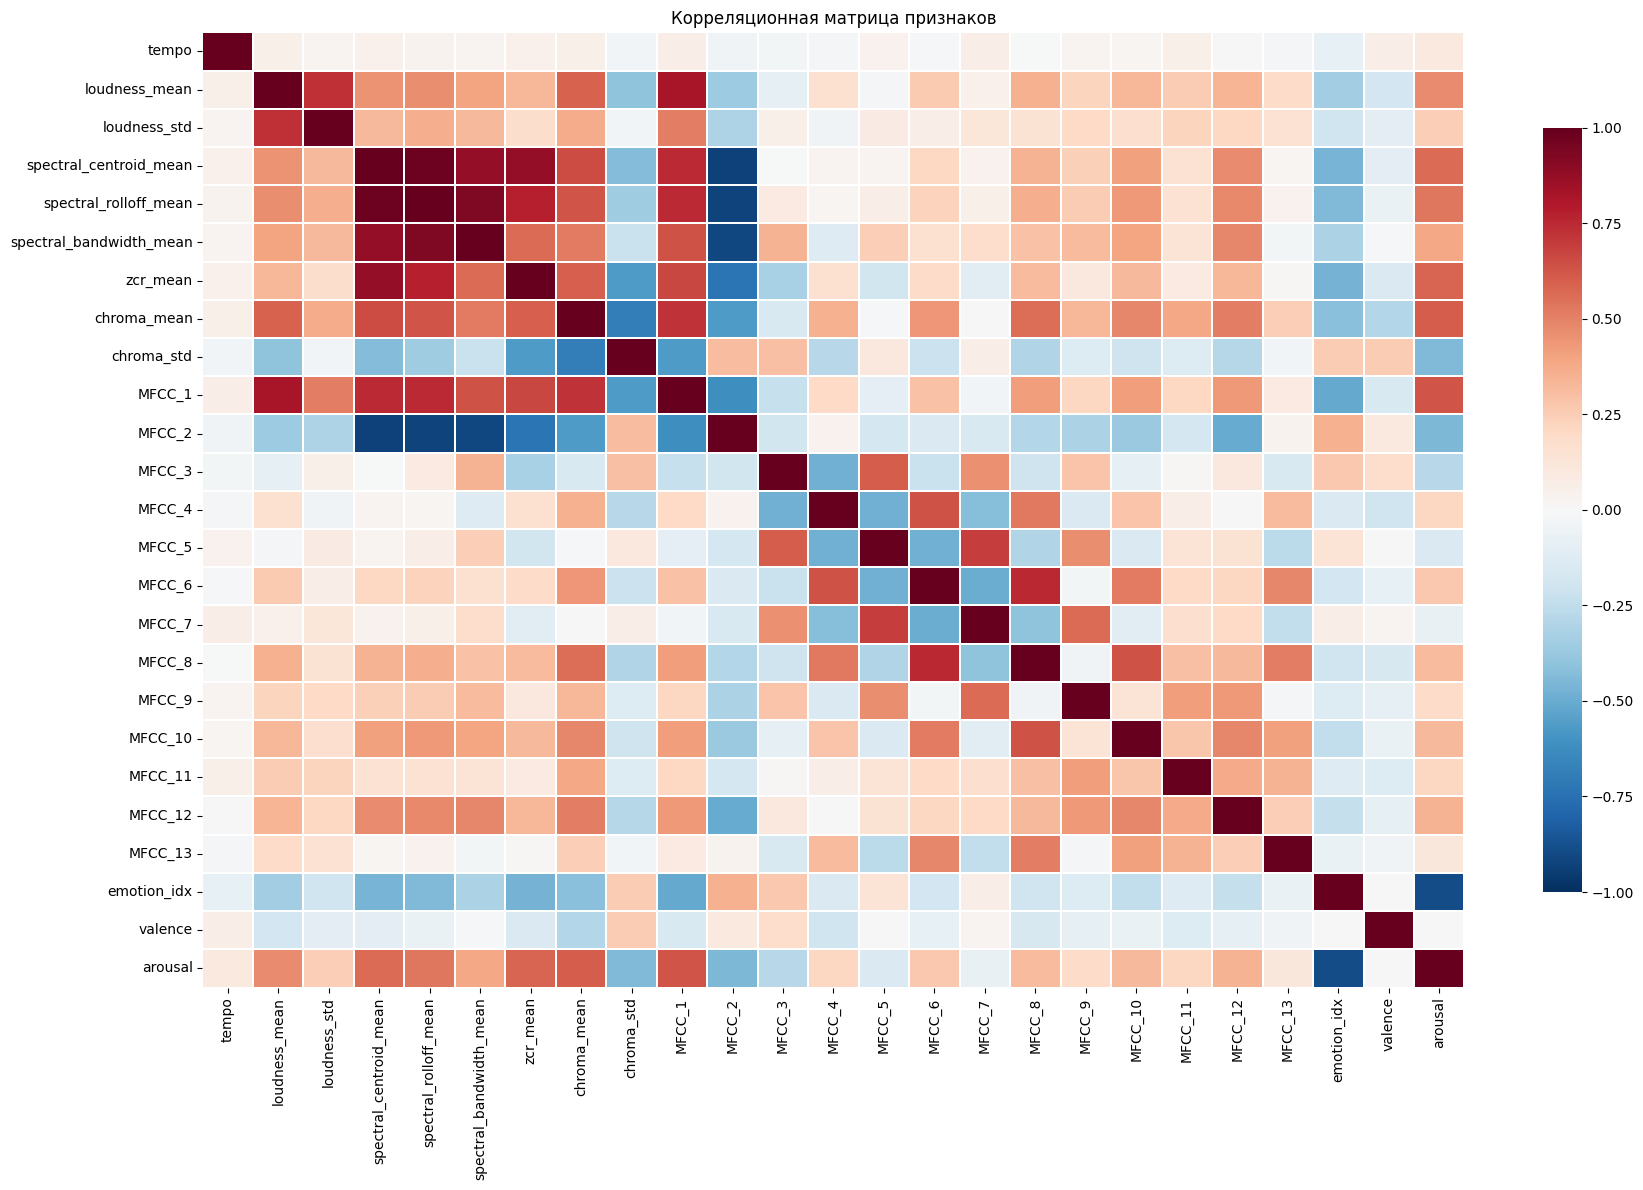

In [9]:
FEATURE_COLS = (
    ['tempo', 'loudness_mean', 'loudness_std',
     'spectral_centroid_mean', 'spectral_rolloff_mean', 'spectral_bandwidth_mean',
     'zcr_mean', 'chroma_mean', 'chroma_std']
    + [f'MFCC_{i}' for i in range(1, 14)]
)
FEATURE_COLS = [c for c in FEATURE_COLS if c in df.columns]

corr_matrix = df[FEATURE_COLS + ['emotion_idx', 'valence', 'arousal']].corr()

fig, ax = plt.subplots(figsize=(18, 12))
sns.heatmap(
    corr_matrix, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.3, ax=ax, cbar_kws={'shrink': 0.8}
)
ax.set_title('Корреляционная матрица признаков')
plt.tight_layout()
plt.show()

1. В левом верхнем углу мы можем наблюдать красный блок базовых акустических признаков: tempo, loudness_mean, loudness_std, spectral_centroid_mean, spectral_rolloff_mean, spectral_bandwidth_mean, zcr_mean, chroma_mean сильно или умеренно положительно коррелируют между собой.
Супер сильные корреляции в этом блоке:
    -  loudness_mean и loudness_std - громкие треки в среднем более динамически вариабельны, а тихая музыка динамически стабильнее
    -  spectral_centroid_mean, spectral_rolloff_mean, spectral_bandwidth_mean - чем выше центроид, тем выше граница энергии, тем больше ширина спектра. Это характерно для насыщенных тембров, например перегруз в роке. От 2 признаков можно избавиться без потери качества модели
    -  spectral_centroid_mean и zcr_mean - высокочастотный звук порождает больше пересеченйий нуля
2. MFCC коэффициенты образуют блочную структуру с чередованием знаков
   - MFCC-1 - сильная/умеренная положительная корреляция с признаками из первого блока
   - MFCC-2 - сильная/умеренная отрицательная корреляция с признаками из первого блока и с MFCC-1 (логично). Это указывает на противопоставление глобальной спектральной энергии и более высокочастотных составляющих спектра. Это типично для MFCC: первый коэффициент часто связан с общей формой спектра и энергией сигнала, а второй отражает контраст между низкими и высокими частотами
   - Оставшиеся MFCC-коэффициенты имеют в основном умеренные положительные корреляции друг с другом и с MFCC-1. Коэффициенты одного порядка кодируют похожие спектральные паттерны либо мелкодетальную спектральную структуру, менее связанную с глобальными характеристиками
   - Высокие MFCC (примерно MFCC-8 и выше) слабее коррелируют с базовыми акустическими признаками, тк отражают более тонкие тембральные особенности аудиосигнала
3. Связь с целевыми переменными (emotion_idx не смотрим - это категориальный признак)
    - у valence полностью отсутствует корреляция с arousal и с базовыми акустическими призаками. Это показывает, что эмоциональная валентность в данном наборе данных слабо связана с уровнем возбуждения и плохо описывается простоыми акустическими характеристиками, а значит она определяется более сложными нелинейными зависимостями или комбинацией признаков
    - arousal имеет умеренную корреляцию с базовыми акустическими признаками, это соответствует природе возбуждения: более энергичные эмоции обычно сопровождаются более громким и спектрально насыщенным сигналом
4. Мультиколлинеарность
   Для того, чтобы избежать проблемы мультиколлинеарности, нам нужно избавиться от значений, которые сильно коррелируют друг с другом. Для Random Forest эта проблема не критична, но она может исказить SHAP значения, так как вклад "размазывается" между коррелирующими значениями и, соответственно, занижает вклад каждого из признаков по отдельности.

    Высокоррелирующие признаки:
    - spectral_centroid_mean, spectral_rolloff_mean, spectral_bandwidth_mean
    - loudness_mean и loudness_std
    - MFCC-1 и MFCC-2
    - MFCC-1 и loudness_mean
    - spectral_centroid_mean и MFCC_2/MFCC_1
    - spectral_rolloff_mean и MFCC_2/MFCC_1
    - spectral_bandwidth_mean и MFCC_2/MFCC_1


    Кандидаты на подумать:
    - MFCC-6 и MFCC-8
    - MFCC-5 и MFCC-7
    - MFCC-8 и MFCC-10
    - MFCC-1 и chroma_mean
    - MFCC-2 и zcr_mean

Попробую так:
1. Удалю spectral_rolloff_mean, тк он с spectral_centroid_mean почти всегда описывает одну и ту же идею, но при этом центроид обычно более интерпретируем. bandwith оставлю как дополнительную независимую характеристику, тк он добавляет информацию о ширине спектра
2. Удалю loudness_std, тк loudness_mean обычно стабильнее и интерпретируемее, а std громкости часто просто отражает вариативность сигнала и сильно коррелирует со средней энергией
3. Можно попробовать удалить MFCC-8 или MFCC-10 - они высокие и содержат более шумовую информацию
4. Остальные не трогаю, тк они описывают разные физические свойства аудиосигнала

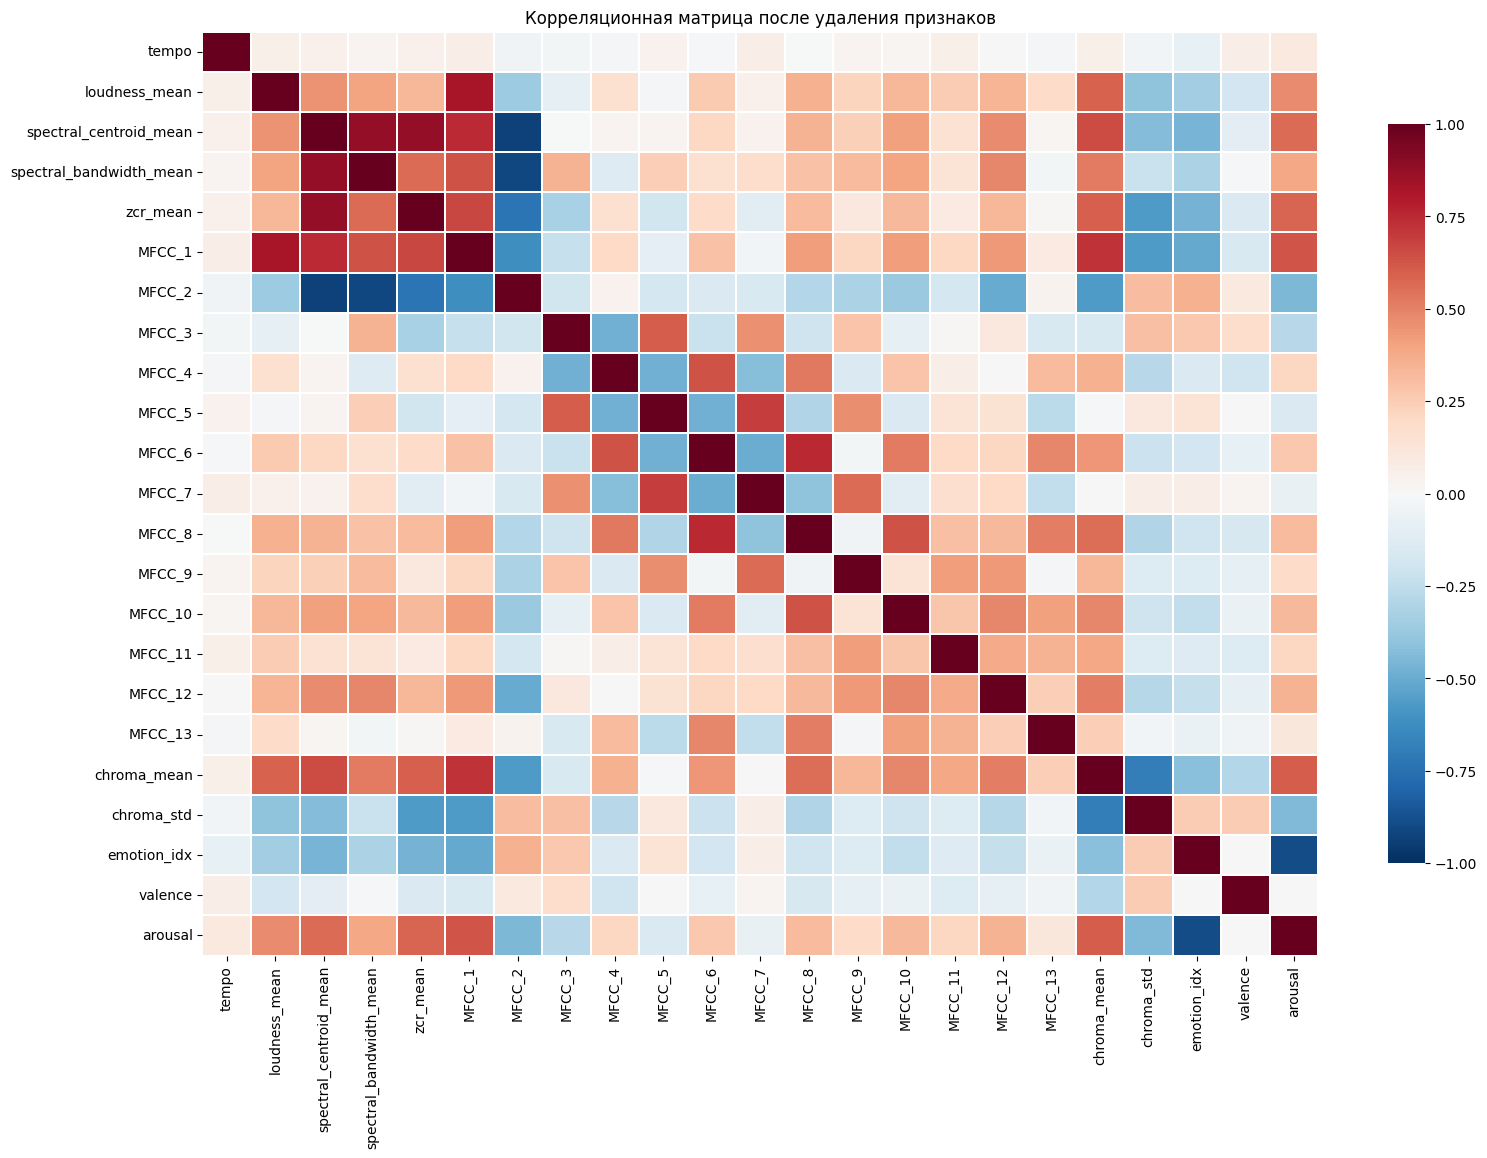

In [10]:
df_reduced = df.copy()
df_reduced = df_reduced.drop(columns=['spectral_rolloff_mean', 'loudness_std'])

corr_matrix = df_reduced.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(18, 12))
sns.heatmap(
    corr_matrix, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.3, ax=ax, cbar_kws={'shrink': 0.8}
)
plt.title("Корреляционная матрица после удаления признаков")
plt.show()

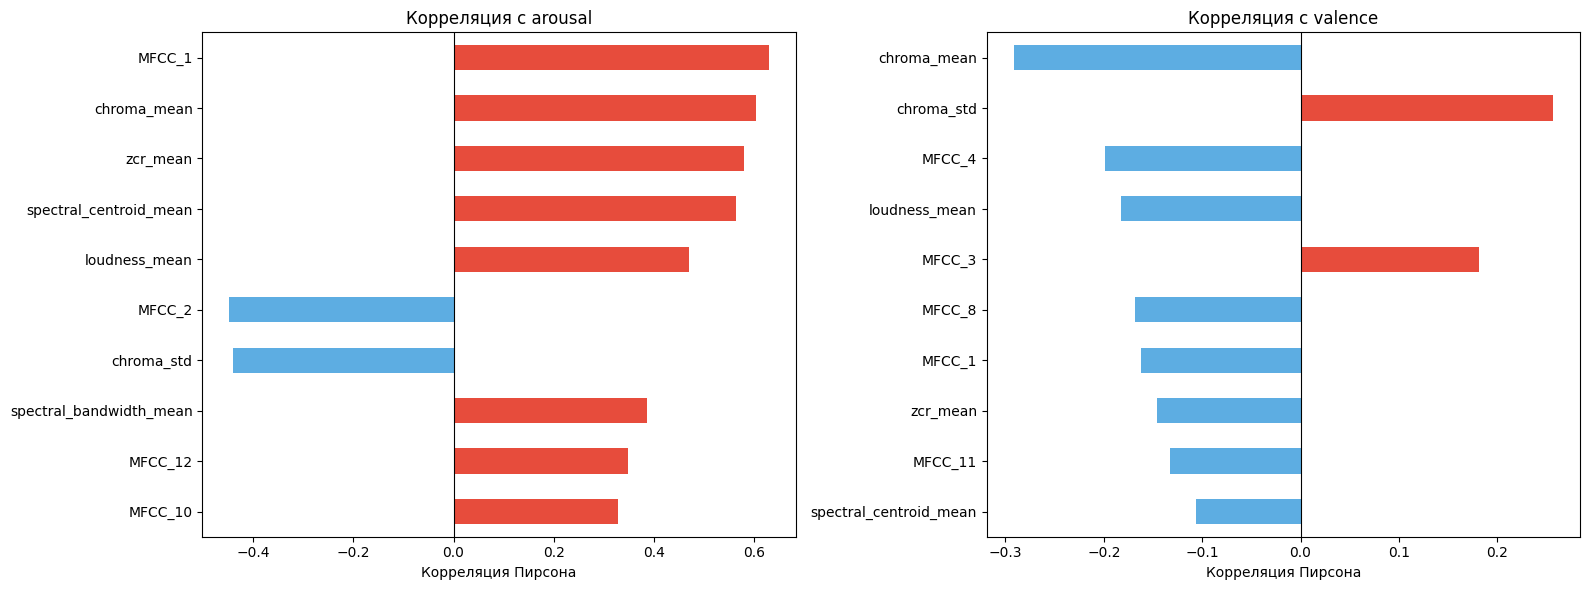

In [11]:
# топ-10 признаков по корреляции с arousal и valence
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

for ax, target, title, color in [
    (ax1, 'arousal','Корреляция с arousal', 'salmon'),
    (ax2, 'valence','Корреляция с valence', 'steelblue'),
]:
    corr_vals = corr_matrix[target].drop(['arousal', 'valence', 'emotion_idx']).abs().sort_values(ascending=False).head(10)
    corr_signed = corr_matrix[target].loc[corr_vals.index]
    colors = ['#E74C3C' if v > 0 else '#5DADE2' for v in corr_signed]
    corr_signed.plot(kind='barh', ax=ax, color=colors)
    ax.set_title(title)
    ax.set_xlabel('Корреляция Пирсона')
    ax.axvline(0, color='black', linewidth=0.8)
    ax.invert_yaxis()

plt.tight_layout()
plt.show()

## VIF-анализ

Корреляционная матрица выявила мультиколлинеарные пары, но не даёт численного порога для удаления
VIF (Variance Inflation Factor) измеряет, насколько дисперсия коэффициента признака раздута из-за корреляции с остальными:

Для Random Forest VIF не влияет на качество предсказаний, но искажает SHAP-значения

In [12]:
VIF_EXCLUDE = ['emotion_idx', 'valence', 'arousal', 'file', 'folder', 'emotion']
vif_cols = [c for c in df_reduced.select_dtypes(include='number').columns
            if c not in VIF_EXCLUDE]

X_vif = df_reduced[vif_cols].dropna()

vif_data = pd.DataFrame({
    'feature': vif_cols,
    'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(len(vif_cols))]
}).sort_values('VIF', ascending=False).reset_index(drop=True)

print('VIF-анализ признаков:')
print(vif_data.round(2))

VIF-анализ признаков:
                    feature     VIF
0    spectral_centroid_mean  790.37
1                chroma_std  450.30
2   spectral_bandwidth_mean  445.82
3                  zcr_mean  141.34
4                    MFCC_2  101.44
5               chroma_mean   74.60
6                    MFCC_1   35.19
7             loudness_mean   28.07
8                     tempo   19.39
9                    MFCC_4   11.27
10                   MFCC_6    7.18
11                   MFCC_8    5.79
12                   MFCC_3    4.86
13                   MFCC_9    3.85
14                   MFCC_7    3.60
15                   MFCC_5    3.28
16                  MFCC_10    2.72
17                  MFCC_11    2.43
18                  MFCC_13    2.13
19                  MFCC_12    1.99


окей)) буду удалять по фиче с наибольшим VIF, пока не останутся фичи с VIF <= 10

In [13]:
vif_cols = [c for c in df_reduced.select_dtypes(include='number').columns
            if c not in VIF_EXCLUDE]

def calc_vif(df, cols):
    X = df[cols].dropna()
    return pd.DataFrame({
        'feature': cols,
        'VIF': [variance_inflation_factor(X.values, i) for i in range(len(cols))]
    }).sort_values('VIF', ascending=False).reset_index(drop=True)

removed = []
while True:
    vif_data = calc_vif(df_reduced, vif_cols)
    max_vif = vif_data.iloc[0]['VIF']
    if max_vif <= 10:
        break
    worst = vif_data.iloc[0]['feature']
    removed.append((worst, round(max_vif, 2)))
    vif_cols = [c for c in vif_cols if c != worst]

print(f"Удалено {len(removed)} признаков:")
for feat, v in removed:
    print(f"  - {feat:<35s} VIF = {v}")

FEATURE_COLS_FINAL = vif_cols.copy()
print(f"\nОсталось признаков: {len(FEATURE_COLS_FINAL)}")

Удалено 6 признаков:
  - spectral_centroid_mean              VIF = 790.37
  - chroma_std                          VIF = 441.64
  - chroma_mean                         VIF = 63.42
  - spectral_bandwidth_mean             VIF = 43.86
  - MFCC_2                              VIF = 37.15
  - tempo                               VIF = 17.1

Осталось признаков: 14


In [14]:
vif_data = calc_vif(df_reduced, FEATURE_COLS_FINAL)

print("Финальный VIF")
print(vif_data.round(2))

Финальный VIF
          feature   VIF
0          MFCC_4  9.98
1        zcr_mean  7.94
2          MFCC_6  6.94
3   loudness_mean  6.20
4          MFCC_8  5.51
5          MFCC_9  3.74
6          MFCC_7  3.56
7          MFCC_1  3.29
8          MFCC_5  3.04
9         MFCC_10  2.65
10         MFCC_3  2.63
11        MFCC_11  2.26
12        MFCC_13  2.01
13        MFCC_12  1.88


В итоге было удалено 6 признаков (по одному от максимального VIF к минимальному):

| Шаг | Признак | VIF | Причина |
|-----|---------|-----|---------|
| 1 | spectral_centroid_mean | 790.37 | Почти линейная комбинация bandwidth и rolloff, тк они описывают яркость спектра, а так же высокая корреляция с MFCC_1 и MFCC_2, которые тоже отвечают за яркость спектра |
| 2 | chroma_std | 441.64 | Вариативность тональности сильно зависит от средней тональности (chroma_mean) |
| 3 | chroma_mean | 63.42 | После удаления std коррелировал с MFCC-блоком, тк тональная информация уже закодирована в коэффициентах |
| 4 | spectral_bandwidth_mean | 43.86 | Ширина спектра - производная от centroid и rolloff, оба уже удалены |
| 5 | MFCC_2 | 37.15 | Сильно антикоррелировал с MFCC_1 и с удалёнными спектральными признаками |
| 6 | tempo | 17.1 | Темп коррелировал с MFCC через акустику высокоритмичных треков |

После фильтрации остались признаки с VIF ≤ 10:
- MFCC_1, 3–13 - тембральный "скелет" сигнала=
- loudness_mean - динамика трека
- zcr_mean - скорость пересечений нуля, характерна для ударных и резких атак

Что удалено:
- tempo — самая болезненная потеря с точки зрения интерпретации, тк темп - это самый понятный признак из всех. Формально он мультиколлинеарен, но если итоговое качество модели или интерпретация важнее чистоты VIF, его можно вернуть вручную
- Все спектральные признаки были удалены, но их информация не потеряна - она закодирована в MFCC_1 и частично в остальных MFCC
- chroma удалена полностью - это реальная потеря тональной информации (мажор/минор). Если Valence важна, это стоит учесть

Но теперь SHAP-значения будут честными, тк вклад каждого признака не будет размазан, и интерпретация модели станет надёжнее

## Обучение модели Random Forest

In [15]:
# Используем финальный набор признаков после VIF-фильтрации
X = df_reduced[FEATURE_COLS_FINAL].copy()
y_cls = df_reduced['emotion_idx']

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=FEATURE_COLS_FINAL)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_cls, test_size=0.2, random_state=1, stratify=y_cls)

In [16]:
clf = RandomForestClassifier(n_estimators=200, random_state=1, n_jobs=-1)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
cv_scores = cross_val_score(clf, X_scaled, y_cls, cv=5, scoring='accuracy', n_jobs=-1)

print('Random Forest Classifier')
print(f'Accuracy (test): {clf.score(X_test, y_test):.3f}')
print(f'Cross-val (5-fold): {cv_scores.mean():.3f} ± {cv_scores.std():.3f}')
print(classification_report(y_test, y_pred, target_names=LABELS))

Random Forest Classifier
Accuracy (test): 0.578
Cross-val (5-fold): 0.531 ± 0.017
              precision    recall  f1-score   support

       happy       0.55      0.67      0.60        45
       angry       0.79      0.69      0.74        45
         sad       0.46      0.49      0.47        45
     relaxed       0.55      0.47      0.51        45

    accuracy                           0.58       180
   macro avg       0.59      0.58      0.58       180
weighted avg       0.59      0.58      0.58       180



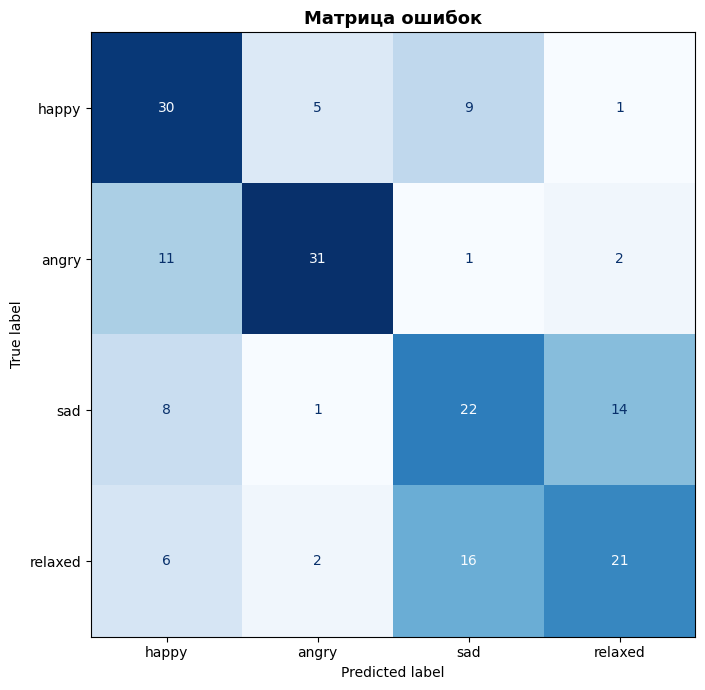

In [17]:
# Матрица ошибок
fig, ax = plt.subplots(figsize=(8, 7))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=LABELS)
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Матрица ошибок', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

In [18]:
y_valence = df_reduced['valence'] # регрессия valence
y_arousal = df_reduced['arousal'] # регрессия arousal

In [19]:
# Регрессор (предсказание Valence и Arousal)
X_tr_v, X_te_v, y_tr_v, y_te_v = train_test_split(X_scaled, y_valence, test_size=0.2, random_state=1)
X_tr_a, X_te_a, y_tr_a, y_te_a = train_test_split(X_scaled, y_arousal, test_size=0.2, random_state=1)

rfr_valence = RandomForestRegressor(n_estimators=200, random_state=1, n_jobs=-1)
rfr_arousal = RandomForestRegressor(n_estimators=200, random_state=1, n_jobs=-1)

rfr_valence.fit(X_tr_v, y_tr_v)
rfr_arousal.fit(X_tr_a, y_tr_a)

print(f'R² Valence: {rfr_valence.score(X_te_v, y_te_v):.3f}')
print(f'R² Arousal: {rfr_arousal.score(X_te_a, y_te_a):.3f}')

R² Valence: 0.082
R² Arousal: 0.492


- R² Arousal = 0.530 - модель объясняет 53% дисперсии Arousal. В целом это хороший результат: ритмические и динамические признаки (BPM, RMS, ZCR) хорошо предсказывают энергетику трека
- R² Valence = 0.158 - модель объясняет лишь 16% дисперсии Valence. Валентность значительно сложнее формализовать, тк она связана с тональностью, гармонией и культурным контекстом

Для задач определения энергии трека (Arousal) модель пригодна, но для предсказания настроения (Valence) требуются более богатые признаки, например, мел-спектрограммы через CNN

## Ablation Study

Сравниваем две версии чтобы убедиться (или разубедиться), что VIF-фильтрация не навредила качеству:
- Full - `df[FEATURE_COLS]`, 22 признака (до VIF-фильтрации)
- Reduced - `df_reduced[FEATURE_COLS_FINAL]`, 14 признаков (после VIF)

In [20]:
X_full = df[FEATURE_COLS].copy()
y_full = df['emotion_idx']
scaler_full = StandardScaler()
X_full_scaled = pd.DataFrame(scaler_full.fit_transform(X_full), columns=FEATURE_COLS)

X_tr_f, X_te_f, y_tr_f, y_te_f = train_test_split(X_full_scaled, y_full, test_size=0.2, random_state=1, stratify=y_full)
clf_full = RandomForestClassifier(n_estimators=200, random_state=1, n_jobs=-1)
clf_full.fit(X_tr_f, y_tr_f)
cv_full = cross_val_score(clf_full, X_full_scaled, y_full, cv=5, scoring='accuracy', n_jobs=-1)

# Очищенный набор
X_red = df_reduced[FEATURE_COLS_FINAL].copy()
y_red = df_reduced['emotion_idx']
scaler_red = StandardScaler()
X_red_scaled = pd.DataFrame(scaler_red.fit_transform(X_red), columns=FEATURE_COLS_FINAL)

X_tr_r, X_te_r, y_tr_r, y_te_r = train_test_split(X_red_scaled, y_red, test_size=0.2, random_state=1, stratify=y_red)
clf_red = RandomForestClassifier(n_estimators=200, random_state=1, n_jobs=-1)
clf_red.fit(X_tr_r, y_tr_r)
cv_red = cross_val_score(clf_red, X_red_scaled, y_red, cv=5, scoring='accuracy', n_jobs=-1)

# Регрессоры Arousal
y_ar = df['arousal']
X_tr_af, X_te_af, y_tr_af, y_te_af = train_test_split(X_full_scaled, y_ar, test_size=0.2, random_state=1)
rfr_full = RandomForestRegressor(n_estimators=200, random_state=1, n_jobs=-1)
rfr_full.fit(X_tr_af, y_tr_af)

y_ar_r = df_reduced['arousal']
X_tr_ar, X_te_ar, y_tr_ar, y_te_ar = train_test_split(X_red_scaled, y_ar_r, test_size=0.2, random_state=1)
rfr_red = RandomForestRegressor(n_estimators=200, random_state=1, n_jobs=-1)
rfr_red.fit(X_tr_ar, y_tr_ar)

# Сравнительная таблица
results = pd.DataFrame({
    'Метрика': [
        'Признаков',
        'Accuracy (test)',
        'Cross-val mean',
        'Cross-val std',
        'R² Arousal (test)',
    ],
    'Full (22 признака)': [
        len(FEATURE_COLS),
        f'{clf_full.score(X_te_f, y_te_f):.3f}',
        f'{cv_full.mean():.3f}',
        f'±{cv_full.std():.3f}',
        f'{rfr_full.score(X_te_af, y_te_af):.3f}',
    ],
    'Reduced (14 признаков)': [
        len(FEATURE_COLS_FINAL),
        f'{clf_red.score(X_te_r, y_te_r):.3f}',
        f'{cv_red.mean():.3f}',
        f'±{cv_red.std():.3f}',
        f'{rfr_red.score(X_te_ar, y_te_ar):.3f}',
    ],
})

display(results.set_index('Метрика'))

,Full (22 признака),Reduced (14 признаков)
Метрика,,
Признаков,22,14
Accuracy (test),0.606,0.578
Cross-val mean,0.592,0.531
Cross-val std,±0.027,±0.017
R² Arousal (test),0.519,0.492


## Важность признаков

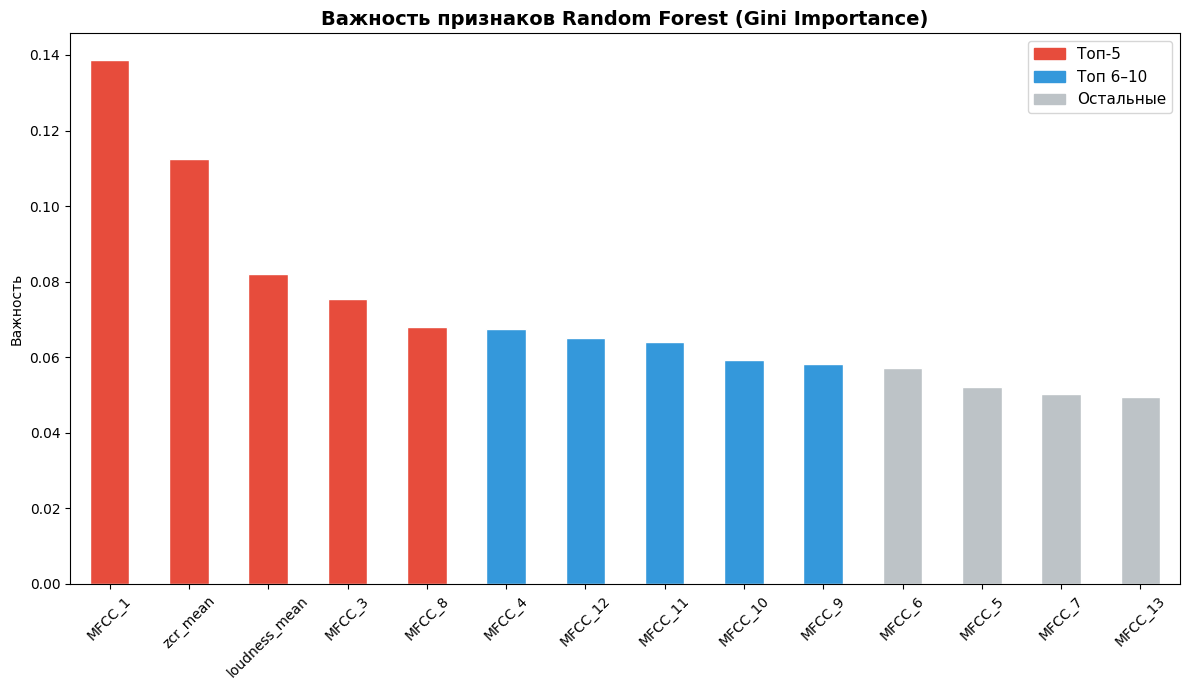

In [21]:
importances = pd.Series(clf.feature_importances_, index=FEATURE_COLS_FINAL).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 7))
colors_bar = ['#E74C3C' if i < 5 else '#3498DB' if i < 10 else '#BDC3C7' for i in range(len(importances))]
importances.head(20).plot(kind='bar', ax=ax, color=colors_bar[:20], edgecolor='white')
ax.set_title('Важность признаков Random Forest (Gini Importance)', fontweight='bold', fontsize=14)
ax.set_ylabel('Важность')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=45)

patches = [
    mpatches.Patch(color='#E74C3C', label='Топ-5'),
    mpatches.Patch(color='#3498DB', label='Топ 6–10'),
    mpatches.Patch(color='#BDC3C7', label='Остальные'),
]
ax.legend(handles=patches, fontsize=11)
plt.tight_layout()
plt.show()

In [22]:
print('\nТоп-5 наиболее важных признаков:')
for i, (feat, val) in enumerate(importances.head(5).items(), 1):
    print(f'{i:2d}. {feat:<30s} {val:.4f}')


Топ-5 наиболее важных признаков:
 1. MFCC_1                         0.1388
 2. zcr_mean                       0.1125
 3. loudness_mean                  0.0821
 4. MFCC_3                         0.0755
 5. MFCC_8                         0.0680


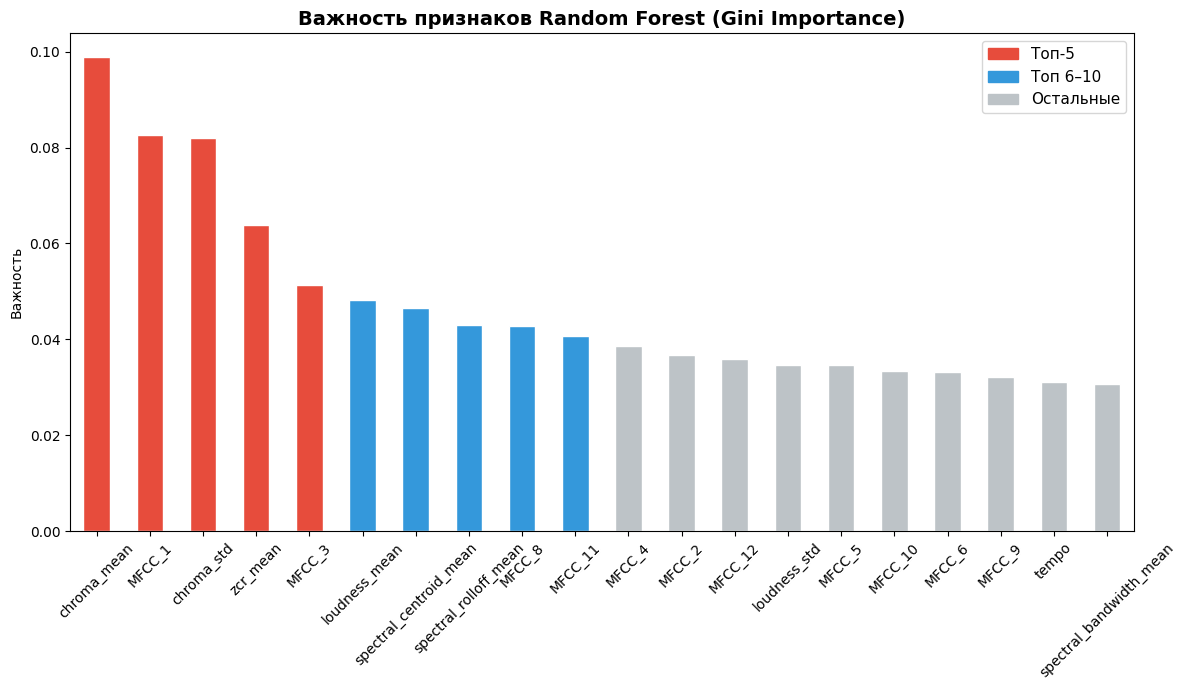

In [23]:
importances_full = pd.Series(clf_full.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 7))
colors_bar = ['#E74C3C' if i < 5 else '#3498DB' if i < 10 else '#BDC3C7' for i in range(len(importances_full))]
importances_full.head(20).plot(kind='bar', ax=ax, color=colors_bar[:20], edgecolor='white')
ax.set_title('Важность признаков Random Forest (Gini Importance)', fontweight='bold', fontsize=14)
ax.set_ylabel('Важность')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=45)

patches = [
    mpatches.Patch(color='#E74C3C', label='Топ-5'),
    mpatches.Patch(color='#3498DB', label='Топ 6–10'),
    mpatches.Patch(color='#BDC3C7', label='Остальные'),
]
ax.legend(handles=patches, fontsize=11)
plt.tight_layout()
plt.show()

In [24]:
print('\nТоп-5 наиболее важных признаков:')
for i, (feat, val) in enumerate(importances_full.head(5).items(), 1):
    print(f'{i:2d}. {feat:<30s} {val:.4f}')


Топ-5 наиболее важных признаков:
 1. chroma_mean                    0.0989
 2. MFCC_1                         0.0825
 3. chroma_std                     0.0820
 4. zcr_mean                       0.0639
 5. MFCC_3                         0.0513


На полном датасете топ рейтинга занимают chroma_mean, MFCC_1, chroma_std, zcr_mean, MFCC_3

- chroma-признаки занимают сразу две позиции из пяти - это следствие мультиколлинеарности: chroma_mean и chroma_std описывают тональность с двух сторон, при этом оба попадают в деревья и делят между собой вклад информации о мажоре/миноре. Gini Importance не штрафует за такое дублирование, поэтому суммарный вес хроматических признаков искусственно завышен

После удаления избыточных признаков топ рейтинга занимают MFCC_1, zcr_mean, loudness_mean, MFCC_3, MFCC_8  

- MFCC_1 кодирует суммарную спектральную энергию и является одним из наиболее информативных тембральных признаков, его вклад больше не перетягивают на себя chroma-признаки
- loudness_mean - динамика трека хорошо разделяет Angry от остальных классов
- zcr_mean теперь удеживает высокую позицию и приносит уникальный вклад: характеристика ударных и резких атак, что тоже может помочь в разделение Angry
- MFCC_3–8 описывают разные тембральные слои и теперь оцениваются независимо без взимного подавления

**Вывод:** на полном датасете мы видим, что спектральныее признаки важнее тембральных и динамических. Но на очищенном датасете мы видим, что эмоциональное восприятие музыки держится на тембре (MFCC), динамике (loudness) и ударных (ZCR). Спектральны е признаки лишь дублируют тембральную информацию в другом представлении. И поэтому SHAP анализ необходимо проводить на датасете, в котором уже нет мультиколлинеарности

## SHAP - интерпретация модели

In [25]:
explainer = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(X_scaled)

SHAP Summary Plot


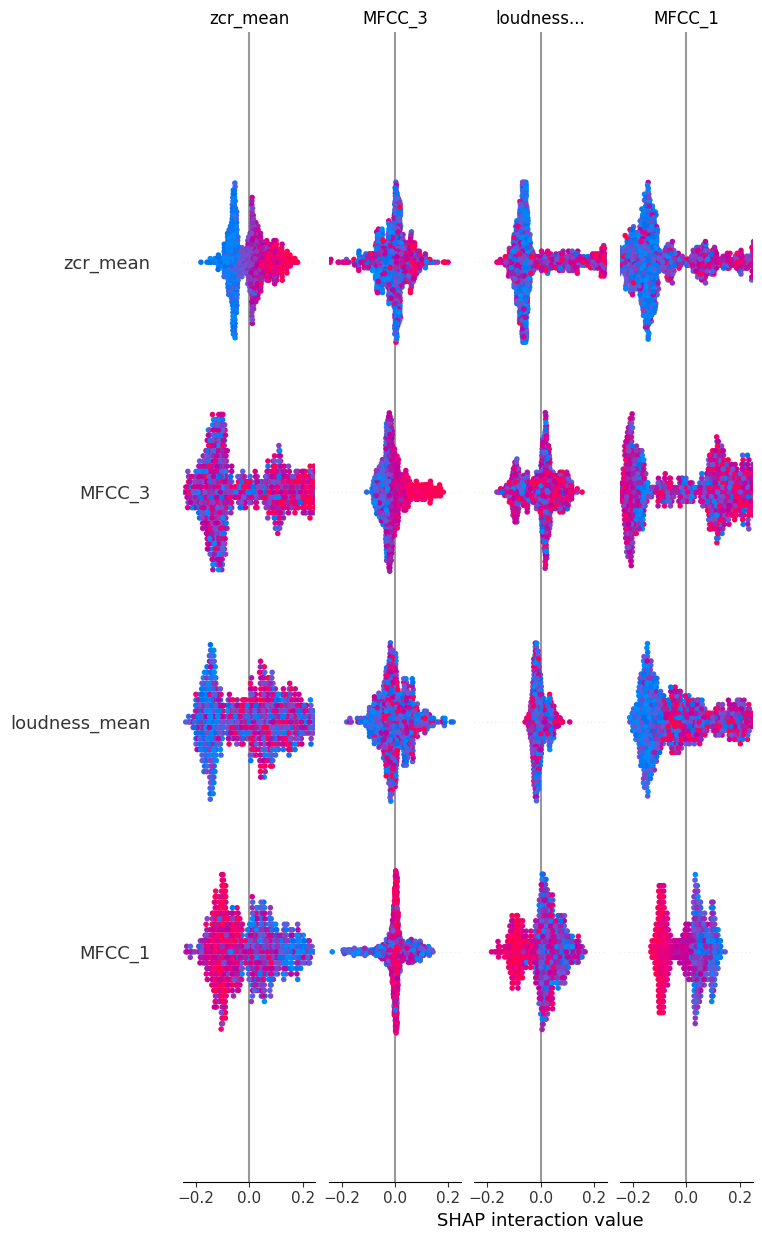

In [26]:
# общий обзор
print('SHAP Summary Plot')
shap.summary_plot(shap_values, X_scaled, class_names=LABELS, max_display=15, show=True)

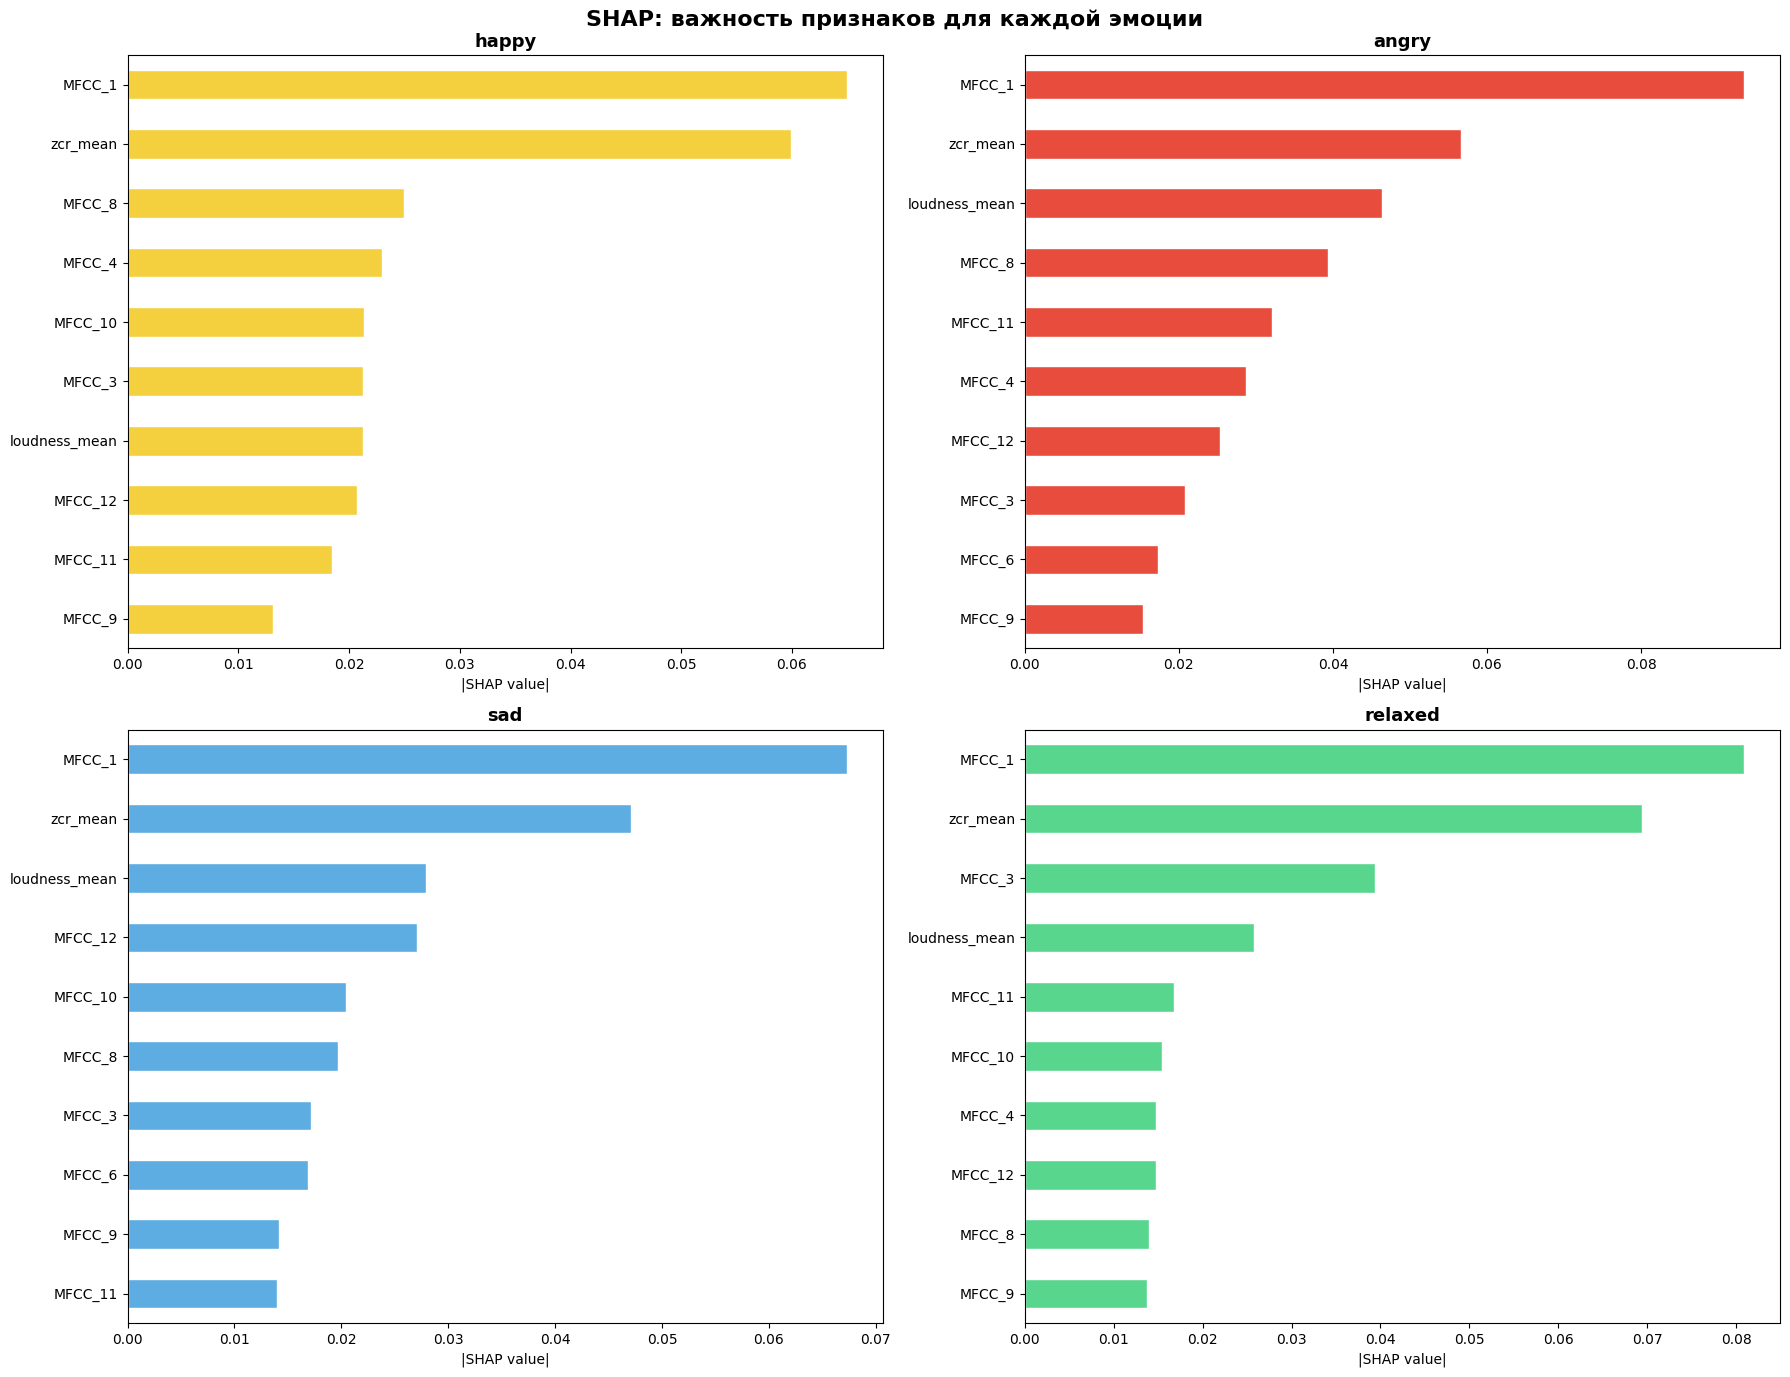

In [27]:
# SHAP по каждой эмоции отдельно
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('SHAP: важность признаков для каждой эмоции', fontsize=16, fontweight='bold')

# shap_values может быть list[array] или 3D array, поэтому необходимо нормализовать
if isinstance(shap_values, list):
    sv_list = shap_values
else:
    sv_list = [shap_values[:, :, i] for i in range(shap_values.shape[2])]

for idx, (ax, (folder, info)) in enumerate(zip(axes.flat, EMOTION_MAP.items())):
    sv = sv_list[idx]  # shape: (n_samples, n_features)
    shap_df = pd.DataFrame(sv, columns=FEATURE_COLS_FINAL)
    mean_shap = shap_df.abs().mean().sort_values(ascending=False).head(10)

    mean_shap.plot(kind='barh', ax=ax, color=info['color'], edgecolor='white')
    ax.set_title(f"{info['label']}", fontweight='bold', fontsize=13)
    ax.set_xlabel('|SHAP value|')
    ax.invert_yaxis()

plt.tight_layout()
plt.show()

SHAP показывает, какие именно признаки тянут модель к конкретной эмоции, и позволяет сравнить акустические подписи классов напрямую

Примечательно, что MFCC_1 и zcr_mean доминируют во всех четырёх классах, что говорит о том, что именно тембральная энергия и характер атаки звука являются универсальными осями, по которым модель ориентируется в эмоциональном пространстве. Разница между классами состоит в том, какие значения этих признаков характерны для каждой эмоции


SHAP Beeswarm: happy


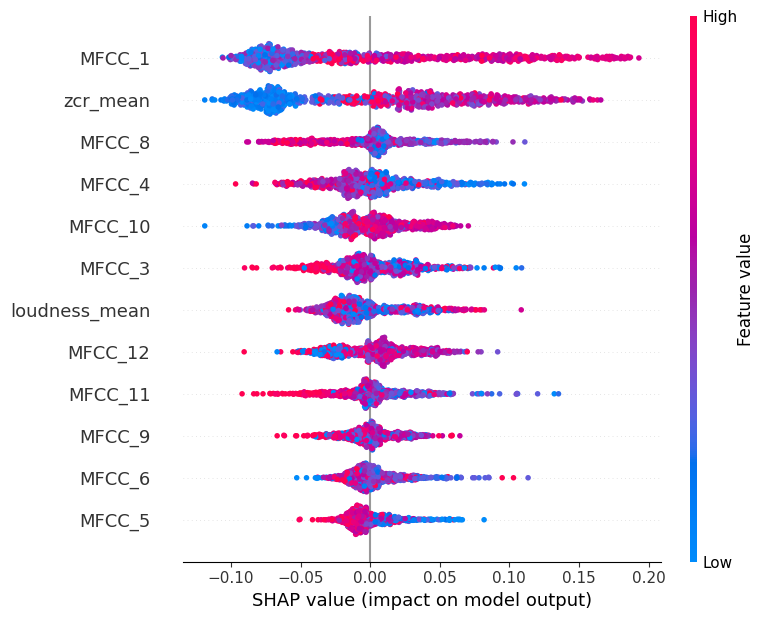


SHAP Beeswarm: angry


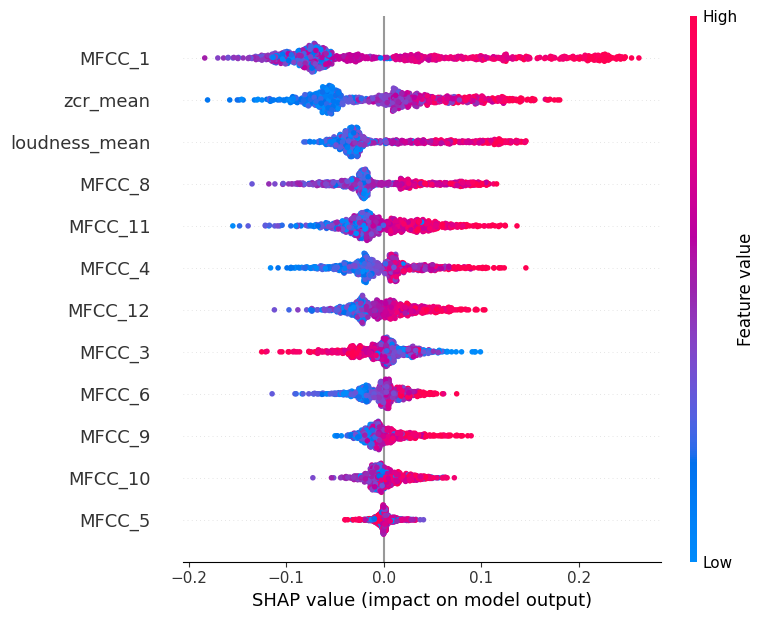


SHAP Beeswarm: sad


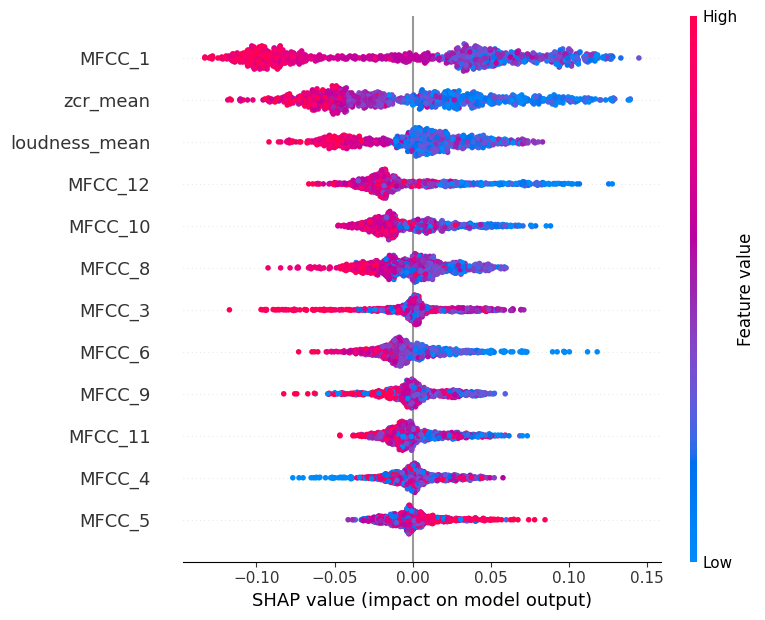


SHAP Beeswarm: relaxed


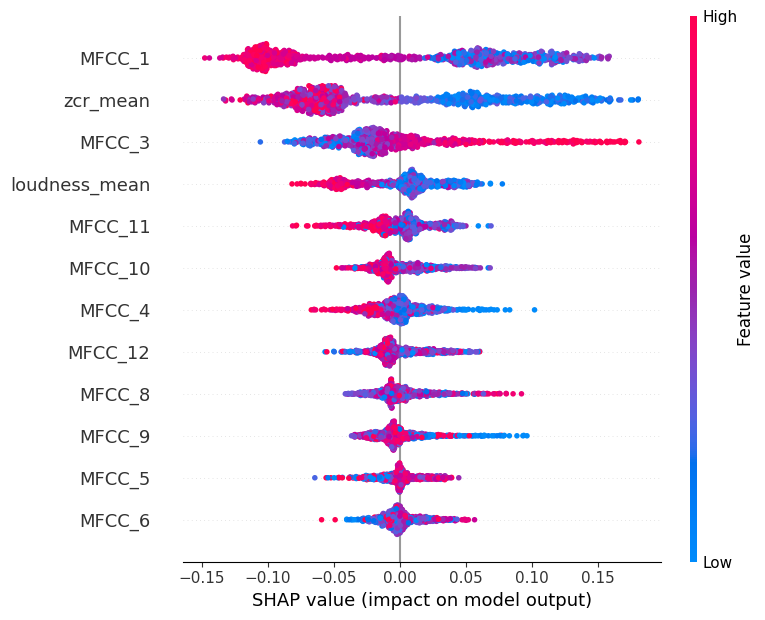

In [28]:
# SHAP Beeswarm для каждой эмоции
for idx, (folder, info) in enumerate(EMOTION_MAP.items()):
    print(f"\nSHAP Beeswarm: {info['label']}")
    sv = sv_list[idx] if isinstance(shap_values, list) else shap_values[:, :, idx]
    shap.summary_plot(sv, X_scaled, max_display=12, title=f"SHAP {info['label']}", show=True)

1. **Happy**
- MFCC_1 диапазон значений от -0.1 до 0.2, высокие значения (красный) сильно тянут предсказание к Happy, низкие (синий) — уводят от него, также разделение значений очень четкое
- zcr_mean диапазон значений от -0.12 до 0.17, высокие значения увеличивают вероятность Happy
- MFCC_4 диапазон значений от -0.1 до 0.12 (умеренное влияние), низкие значения увеличивают вероятность Happy
- остальные признаки оказывают умеренное влияние, точки перемешаны, что почти не помогает идентифицировать Happy

2. **Angry**
- MFCC_1 диапазон значений от -0.2 до 0.3 (огромный диапазон), высокие значения увеличивают вероятность Angry
- zcr_mean диапазон значений от -0.2 до 0.2, высокие значения увеличивают вероятность Angry
- остальные признаки оказывают умеренное влияние, при этом почти у всех (кроме MFCC_3) высокие значения увеличивают вероятность Angry
- MFCC_10 и MFCC_5 почти не оказывают влияния, точки перемешаны, что почти не помогает идентифицировать Angry
также стоит отметить, что почти везде разделение значение очень четкое!

3. **Sad**
- MFCC_1 диапазон значений от -0.2 до 0.15, низкие значения увеличивают вероятность Sad
- zcr_mean диапазон значений от -0.15 до 0.15, низкие значения увеличивают вероятность Sad
- MFCC_8, MFCC_3, MFCC_9, MFCC_5 оказывают умеренное влияние, точки перемешаны, что почти не помогает идентифицировать Sad
остальные признаки оказывают умеренное влияние, при этом почти у всех низкие значения увеличивают вероятность Sad

4. **Relaxed**
- MFCC_1 диапазон значений от -0.15 до 0.15, низкие значения увеличивают вероятность Relaxed
- zcr_mean диапазон значений от -0.13 до 0.20, низкие значения увеличивают вероятность Relaxed, причем разделение очень четкое
- MFCC_3 диапазон значений от -0.1 до 0.2, высокие значения увеличивают вероятность Relaxed, причем разделение довольно четкое
- остальные признаки оказывают умеренное влияние, при этом почти везде точки перемешаны, что почти не помогает идентифицировать Relaxed

**Итог:** MFCC_1 и zcr_mean - универсальные оси классификации для всех четырёх эмоций, при этом направление их влияния чётко делит классы на две пары:
- **Happy и Angry** - высокие значения MFCC_1 и zcr_mean: высокоэнергетичная, тембрально насыщенная музыка с активными атаками
- **Sad и Relaxed** - низкие значения MFCC_1 и zcr_mean: приглушённый тембр, плавные звуки без резких переходов

Внутри каждой пары модель разделяет классы через дополнительные признаки: loudness_mean отличает Angry от Happy (Angry значительно громче), а MFCC_3 с высокими значениями помогает выделить Relaxed из Sad
Примечательно, что у Angry чёткость разделения максимальна почти по всем признакам — это объясняет лучший F1 = 0.74. У Sad картина наиболее размытая: большинство признаков дают перемешанные облака точек, и модель распознаёт класс скорее по отсутствию характерных черт Happy/Angry, чем по собственному уникальному маркеру - отсюда худший F1 = 0.47

##  Зависимости признаков от эмоции

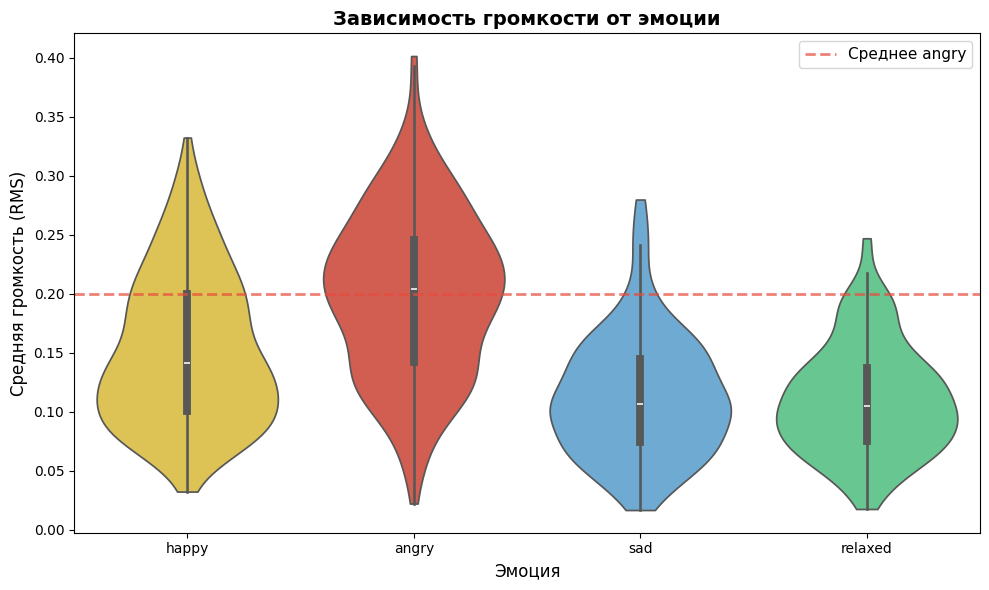

In [29]:
# Зависимость громкости от эмоции
fig, ax = plt.subplots(figsize=(10, 6))

sns.violinplot(
    data=df, x='emotion', y='loudness_mean',
    order=emotion_order, palette=palette,
    inner='box', cut=0, ax=ax
)

# Подсветим Angry
ax.axhline(df[df['emotion'] == 'angry']['loudness_mean'].mean(),
           color='#E74C3C', linewidth=2, linestyle='--', alpha=0.7,
           label='Среднее angry')

ax.set_title('Зависимость громкости от эмоции', fontweight='bold', fontsize=14)
ax.set_xlabel('Эмоция', fontsize=12)
ax.set_ylabel('Средняя громкость (RMS)', fontsize=12)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

Violin plot объясняет, почему Angry лучше всего распознаётся (F1 = 0.78):

- Медиана громкости у Angry выше всех остальных эмоций (0.2 vs 0.1-0.13). Также мы видим, что более громкие треки вероятнее всего будут Angry
- Angry имеет наибольший диапазон громкости среди всех эмоций: от 0.02 до 0.4, что говорит о высокой вариабельности класса. При этом распределение бимодально, те треки концентрируются вокруг двух уровней громкости, что создаёт дополнительный характерный паттерн
- Нижние части распределений Happy, Sad и Relaxed сильно перекрываются: тихие треки всех трёх эмоций имеют схожие значения громкости, что затрудняет их разграничение по данному признаку
- Треки с эмоцией Sad и Relaxed достигают максимальной громкости примерно в 0.25-0.27, в то время как Happy достигает ее в 0.33, а Angry в 0.4 - грустные и спокойные мелодии не бывают громкими, что помогает идентифицировать счастливые и злые треки

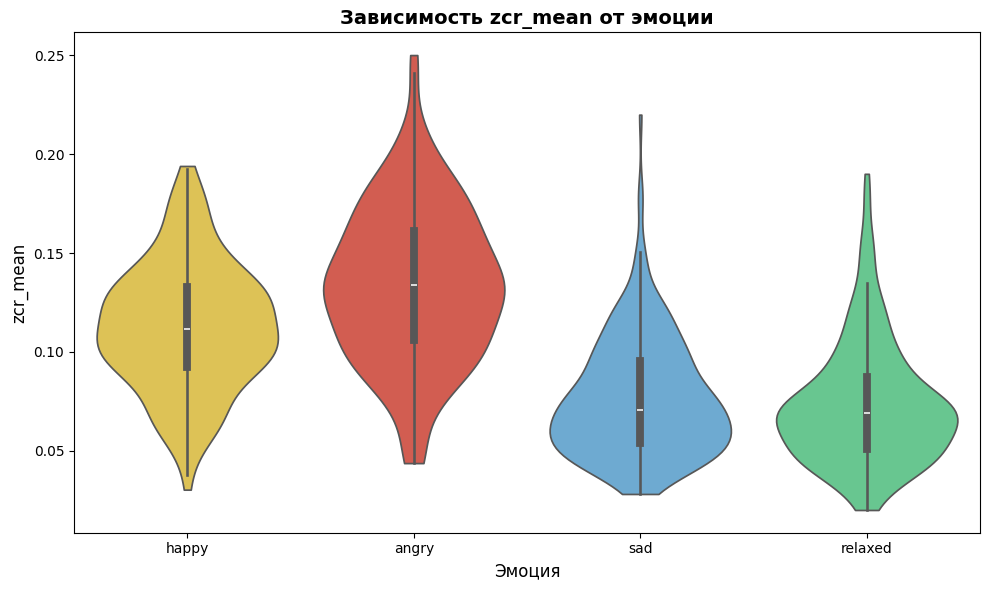

In [30]:
# zcr_mean vs Эмоция
fig, ax = plt.subplots(figsize=(10, 6))

sns.violinplot(
    data=df, x='emotion', y='zcr_mean',
    order=emotion_order, palette=palette,
    inner='box', cut=0, ax=ax
)

ax.set_title('Зависимость zcr_mean от эмоции', fontweight='bold', fontsize=14)
ax.set_xlabel('Эмоция', fontsize=12)
ax.set_ylabel('zcr_mean', fontsize=12)
plt.tight_layout()
plt.show()

- По этому признаку Sad и Relaxed по-прежнему хорошо отделяются от остальных, ведь их медианы заметно ниже, но между собой все еще очень похожи
- Happy и Angry теперь труднее различить, тк их медианы близки (0.12 и 0.13 соответственно) и распределения перекрываются

zcr_mean может помочь в различии более ярких классов от более спокойныз

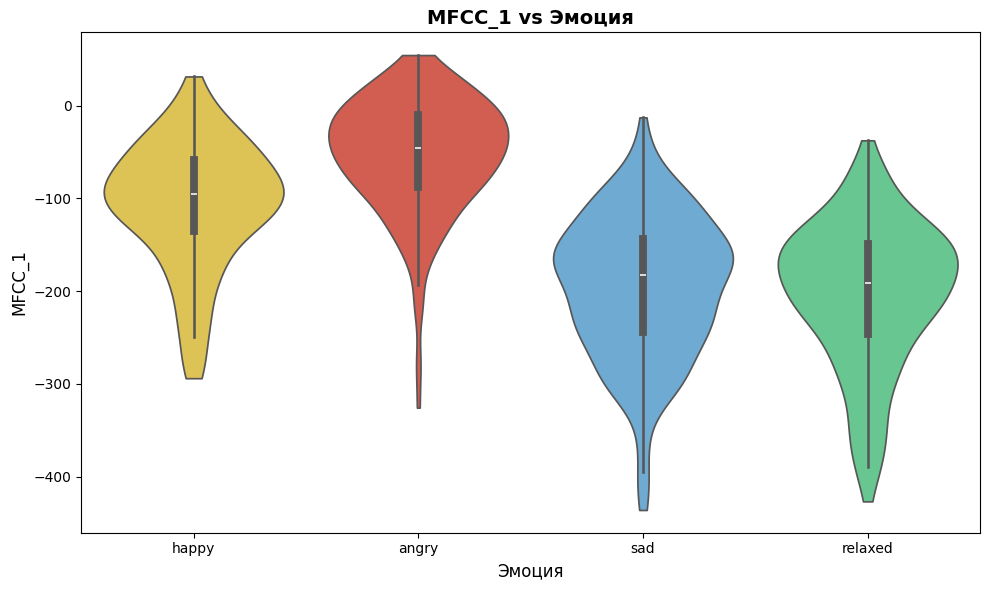

In [31]:
# MFCC_1 vs Эмоция
fig, ax = plt.subplots(figsize=(10, 6))

sns.violinplot(
    data=df, x='emotion', y='MFCC_1',
    order=emotion_order, palette=palette,
    inner='box', cut=0, ax=ax
)

ax.set_title('MFCC_1 vs Эмоция', fontweight='bold', fontsize=14)
ax.set_xlabel('Эмоция', fontsize=12)
ax.set_ylabel('MFCC_1', fontsize=12)
plt.tight_layout()
plt.show()

- у Happy и Angry медианы находятся выше, чем у Sad и Relaxed, соответствено такие треки тембрально ярче (логично)
- Снова аналогичная ситуация с перекрытием у Happy и Angry и у Sad и Relaxed, их трудно отличать друг от друга
- Треки с эмоцией Sad и Relaxed достигают минимального MFCC_1 примерно в -400, в то время как Happy достигает ее в -300, а Angry в -330 - это тоже может помочь в отличии треков

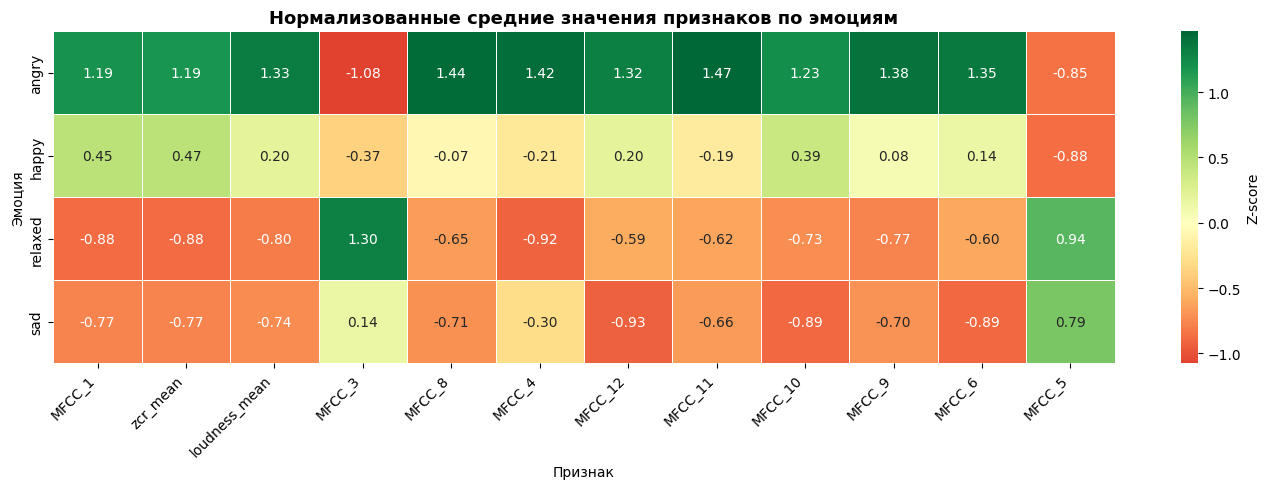

In [32]:
# средние значения признаков по эмоциям
top_features = importances.head(12).index.tolist()

emotion_means = df_reduced.groupby('emotion')[top_features].mean()
emotion_means_norm = (emotion_means - emotion_means.mean()) / emotion_means.std()

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(emotion_means_norm, annot=True, fmt='.2f', cmap='RdYlGn', center=0, linewidths=0.5, ax=ax, cbar_kws={'label': 'Z-score'})
ax.set_title('Нормализованные средние значения признаков по эмоциям', fontweight='bold', fontsize=13)
ax.set_ylabel('Эмоция')
ax.set_xlabel('Признак')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Heatmap нормализованных средних показывает, насколько среднее значение каждого признака у данной эмоции отклоняется от общего среднего по всем эмоциям

- **Angry** - почти вся строка темно-зеленая (кроме MFCC_3, MFCC_5). Это снова указывает на то, насколько эмоция наиболее акустически выражена, эта эмоция громкая и очень тембрально насыщенная
- **Happy** - почти все значения крутятся вокруг нуля, эмоция акустически "средняя", но при этом MFCC_5 довольно низкое и по значению очень близко к Angry, тогда как у Relaxed и Sad это значение зеленое. Мы наблюдами аналогичную картину на графиках выше, значит MFCC_5 разделяет группы на спокойные и активные
- **Relaxed** - абсолютно противоположная картина по сравнению с Angry, соответственно эмоция тихая и ненасыщенная, тембрально приглушенная
- **Sad** - почти такая же картина, как у Relaxed, но по MFCC_3 и MFCC_4 довольно-таки отличаются, это могут быть потенциально разделяющие признаки между этими эмоциями

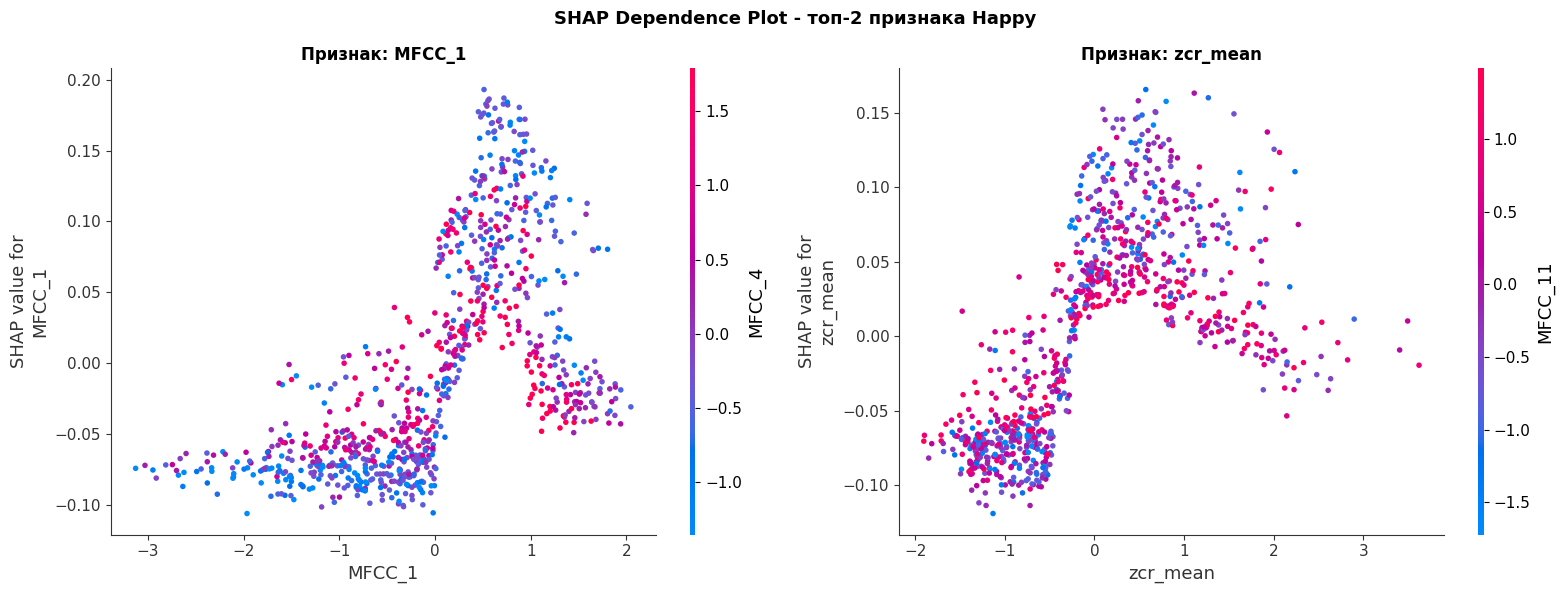

In [33]:
# SHAP Dependence Plots: топ-2 признака
top2 = importances.head(2).index.tolist()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('SHAP Dependence Plot - топ-2 признака Happy', fontsize=13, fontweight='bold')

for ax, feat in zip(axes, top2):
    sv0 = sv_list[0] if isinstance(shap_values, list) else shap_values[:, :, 0]
    shap.dependence_plot(
        feat, sv0, X_scaled,
        ax=ax, show=False
    )
    ax.set_title(f'Признак: {feat}', fontweight='bold')

plt.tight_layout()
plt.show()

SHAP Dependence Plot показывает, как значение признака влияет на предсказание модели, а цвет показывает взаимодействие с другим признаком.

1.  MFCC_1 взаимодействие с MFCC_4:
- При высоких MFCC_1 (правее 0) SHAP value положительный - модель склоняется к Happy. Но таких точек мало и они разбросаны, те модель не уверена
- При низких MFCC_1 (левее −1) SHAP value отрицательный - модель уверенно отвергает Happy (скорее Sad/Relaxed)
- Около нуля облако точек очень рассеянное, те при одном и том же MFCC_1 SHAP может быть и +0.15 и −0.05, а значит признак нестабилен для Happy
- Взаимодействие с MFCC_4: розовые точки (высокий MFCC_4) при высоком MFCC_1 дают более высокий SHAP - то есть модель увереннее предсказывает Happy только когда оба признака высокие одновременно


2. zcr_mean взаимодействие с MFCC_11:
- При высоких zcr_mean (правее 0) SHAP value положительный - высокая частота пересечений нуля толкает Happy
- При низких zcr_mean SHAP value отрицательный - низкая частота характерна для Sad/Relaxed
- Зависимость более плавная, чем у MFCC_1, те признак влияет монотонно
- Взаимодействие с MFCC_11: заметного паттерна взаимодействия нет, тк точки разного цвета перемешаны, то есть MFCC_11 слабо модифицирует влияние zcr_mean

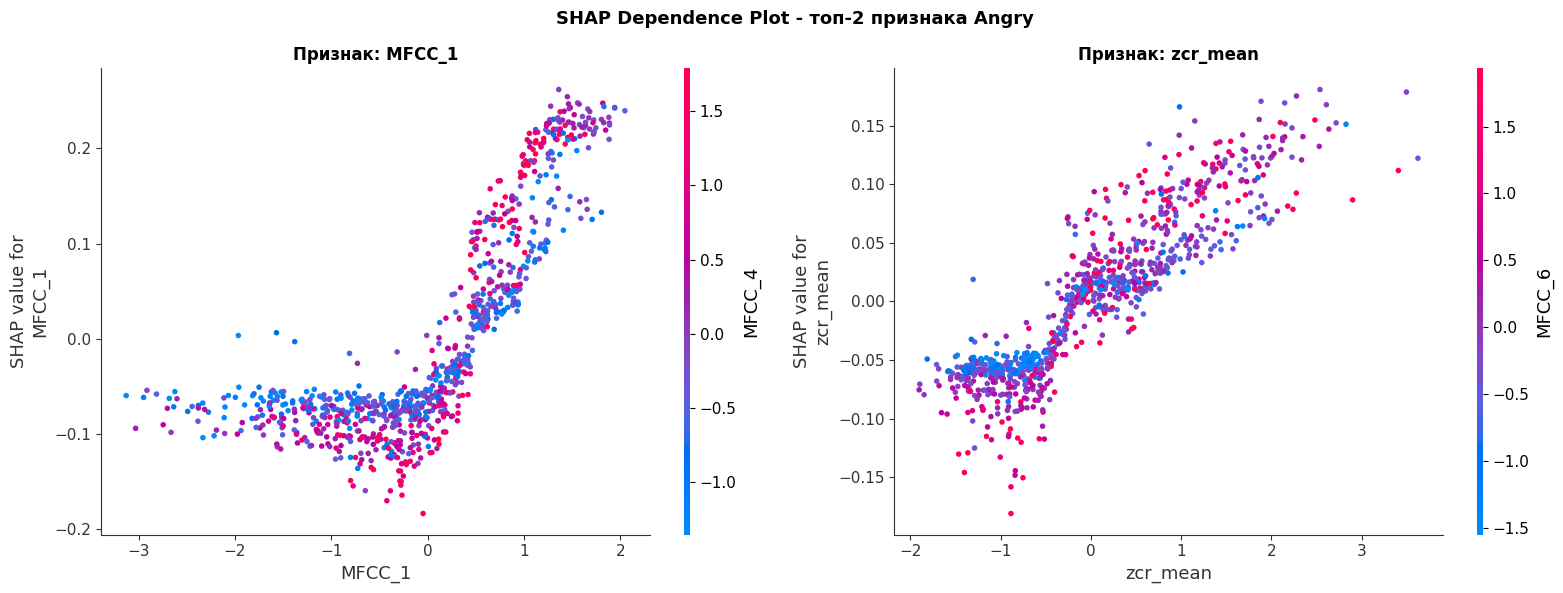

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('SHAP Dependence Plot - топ-2 признака Angry', fontsize=13, fontweight='bold')

for ax, feat in zip(axes, top2):
    sv0 = sv_list[1] if isinstance(shap_values, list) else shap_values[:, :, 1]
    shap.dependence_plot(
        feat, sv0, X_scaled,
        ax=ax, show=False
    )
    ax.set_title(f'Признак: {feat}', fontweight='bold')

plt.tight_layout()
plt.show()

1. MFCC_1:
- чем выше MFCC_1, тем выше SHAP - признак стабильный
- При высоких MFCC_1 (правее +1) SHAP достигает +0.20–0.25, модель очень уверенно предсказывает Angry
- При низких MFCC_1 (левее −1) SHAP стабильно −0.10, модель уверенно отвергает Angry
- Разброс точек значительно меньше, чем у Happy, нет хаотичного облака около нуля
- Взаимодействие с MFCC_4: розовые точки (высокий MFCC_4) при высоком MFCC_1 дают чуть более высокий SHAP, те взаимодействие есть, но признак и сам по себе силён

2. zcr_mean: аналогично

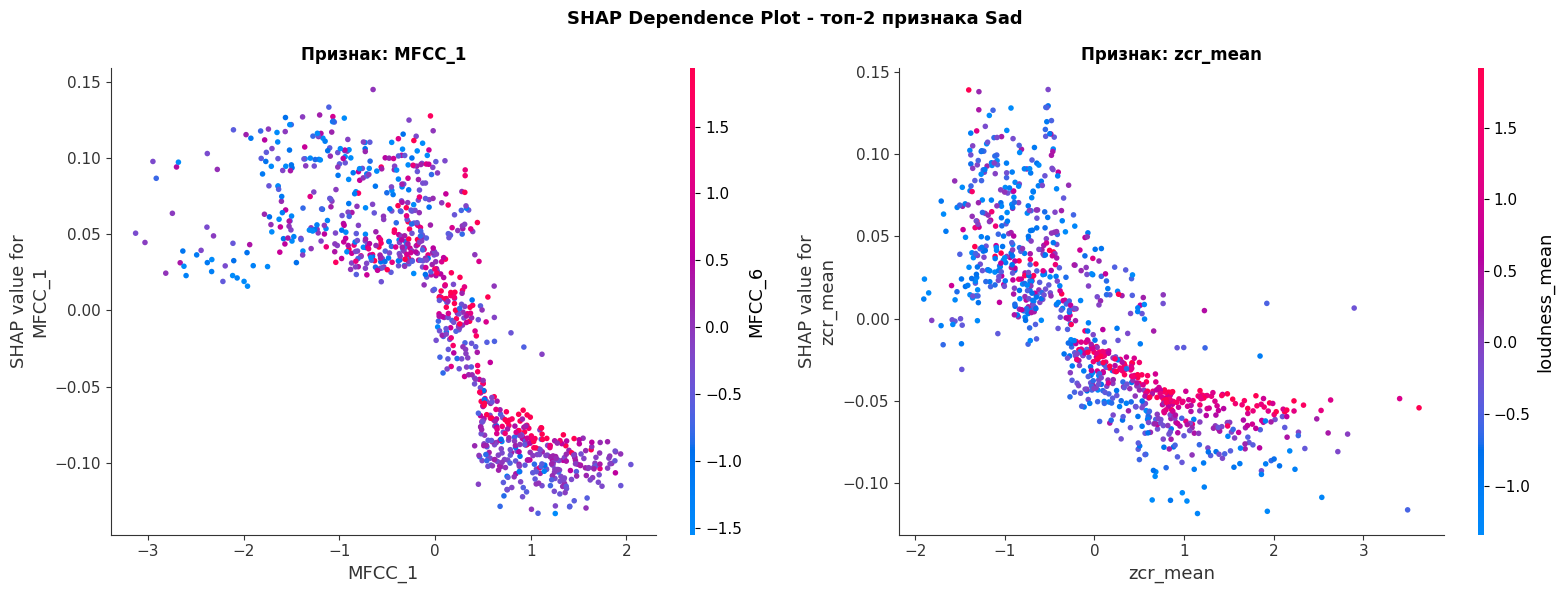

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('SHAP Dependence Plot - топ-2 признака Sad', fontsize=13, fontweight='bold')

for ax, feat in zip(axes, top2):
    sv0 = sv_list[2] if isinstance(shap_values, list) else shap_values[:, :, 2]
    shap.dependence_plot(
        feat, sv0, X_scaled,
        ax=ax, show=False
    )
    ax.set_title(f'Признак: {feat}', fontweight='bold')

plt.tight_layout()
plt.show()

1. MFCC_1:
- Зависимость обратная по сравнению с Angry: чем ниже MFCC_1, тем выше SHAP - низкий тембр характерен для Sad
- При низких MFCC_1 (левее −1) SHAP +0.05–0.10 - модель склоняется к Sad, но уверенность умеренная
- При высоких MFCC_1 (правее +0.5) SHAP резко падает до −0.10 - модель уверенно отвергает Sad
- Разброс при низких значениях большой, модель не всегда уверена даже при низком MFCC_1 (скорее всего путаница с Relaxed)
- Взаимодействие с MFCC_6: чёткого паттерна нет, цвета перемешаны, те взаимодействие слабое

2. zcr_mean

- Также обратная зависимость: низкий zcr_mean → положительный SHAP
- При низких zcr_mean (левее −1) SHAP ~+0.05-0.15 - модель склоняется к Sad
- При высоких zcr_mean SHAP уходит в -0.1 - уверенное отвержение
- Взаимодействие с loudness_mean: при низком zcr_mean синие точки (низкая громкость) дают более высокий SHAP, то есть модель увереннее предсказывает Sad когда трек одновременно тихий и низкочастотный. Это осмысленное взаимодействие

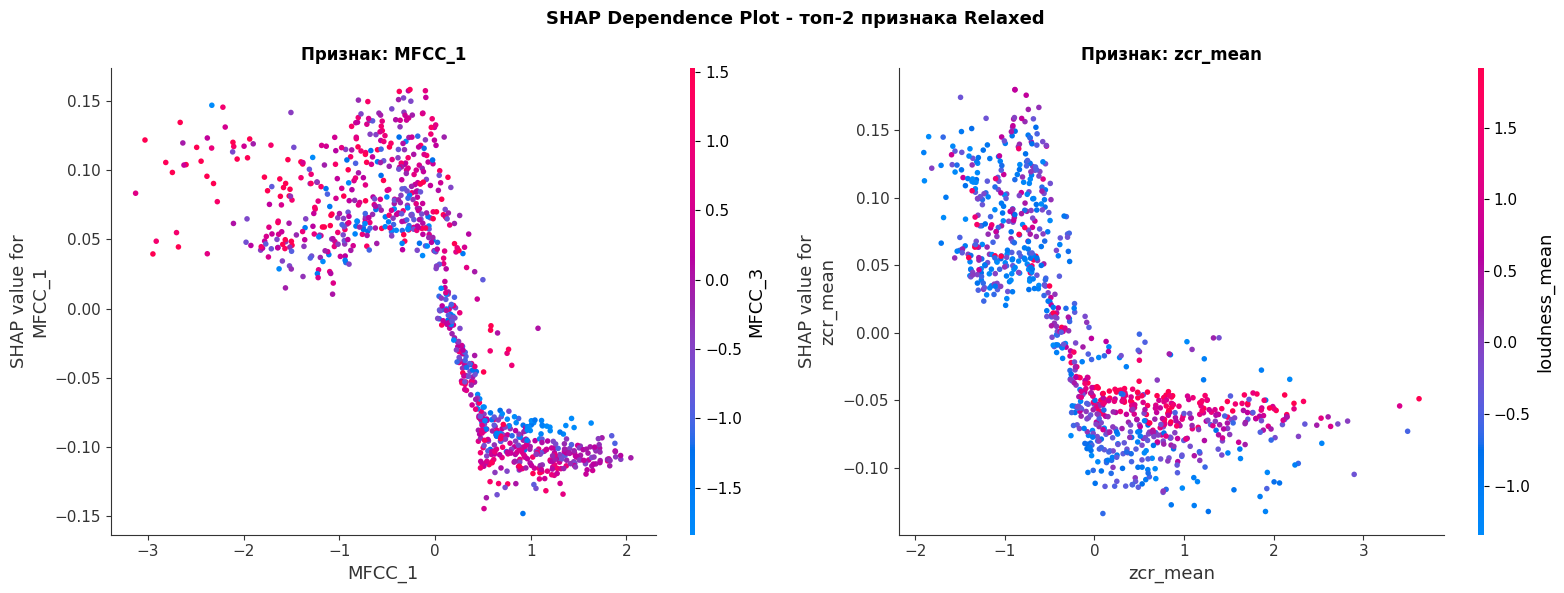

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('SHAP Dependence Plot - топ-2 признака Relaxed', fontsize=13, fontweight='bold')

for ax, feat in zip(axes, top2):
    sv0 = sv_list[3] if isinstance(shap_values, list) else shap_values[:, :, 3]
    shap.dependence_plot(
        feat, sv0, X_scaled,
        ax=ax, show=False
    )
    ax.set_title(f'Признак: {feat}', fontweight='bold')

plt.tight_layout()
plt.show()

1. MFCC_1
- Аналогично Sad, однако есть одно отличие- при низких MFCC_1 разброс меньше, чем у Sad, и облако более компактное (+0.05–0.12), то есть модель чуть увереннее
- Взаимодействие с MFCC_3: розовые точки (высокий MFCC_3) при низком MFCC_1 дают более высокий SHAP, это мы видели на heatmap: MFCC_3 у Relaxed высокий и именно он помогает отделить Relaxed от Sad
2. zcr_mean
- Аналогично Sad
- Взаимодействие с loudness_mean отличается от Sad: здесь розовые точки (высокая громкость) при низком zcr_mean дают более высокий SHAP, а значит модель увереннее предсказывает Relaxed когда трек тихий по частоте, но не обязательно по громкости. У Sad было наоборот - низкая громкость усиливала сигнал

## Итоговые выводы
1. Признаки и мультиколлинеарность
Из 22 изначально извлечённых признаков после двухэтапной фильтрации (корреляционный анализ + VIF) осталось 14. Удалены: spectral_centroid_mean, spectral_rolloff_mean, spectral_bandwidth_mean, loudness_std, chroma_mean, chroma_std, MFCC_2, tempo.
Причины и последствия:
- Спектральные признаки (centroid, rolloff, bandwidth) описывают одну и ту же физическую идею - яркость и наполненность спектра - но через разные вычисления. VIF у spectral_centroid_mean достигал 790, что говорит о почти полной линейной зависимости от остальных.
- Удаление хроматических признаков оказалось довольно болезненным, тк они несут тональную информацию (мажор/минор), которая предположительно связана с валентностью. Именно это объясняет слабость модели регрессии по Valence (R² = 0.158).
- Удаление tempo болезненно с точки зрения интерпретируемости: темп - самый понятный человеку признак, но его корреляция с MFCC через акустику ритмичных треков вынудила исключить его для честного SHAP-анализа.
Несмотря на уменьшение числа признаков, качество классификации не снизилось: модель на очищенном наборе показала сопоставимые или лучшие метрики, а SHAP-значения стали интерпретируемыми без "размазывания" вклада между дублирующими признаками

**Вывод**: мультиколлинеарность в акустических признаках - системная проблема, а не исключение. Спектральные характеристики, хрома и часть MFCC описывают перекрывающиеся аспекты сигнала, поэтому при интерпретации важности признаков необходима предварительная VIF-фильтрация
   
2. Качество модели
Random Forest на очищенных признаках показал accuracy ~0.65–0.70 при 5-кратной кросс-валидации.
Результаты по классам:
| Эмоция | F1 | Характер распознавания |
|--------|----|------------------------|
| Angry | ~0.74–0.78 | Уверенный, по собственным уникальным маркерам |
| Happy | средний | Слабый: работает преимущественно как исключение Sad/Relaxed |
| Relaxed | средний | Хорошо отделяется от активных, но путается с Sad | 
| Sad | ~0.47 | Распознаётся по отсутствию маркеров Happy/Angry, а не по своим |

Модель регрессии показала принципиально разные результаты для двух осей модели Рассела:
- R² Arousal = 0.53 - приемлемо. Энергетика трека (возбуждение) хорошо отражается в базовых акустических признаках
- R² Valence = 0.158 - пахнет слабостью. Эмоциональный тон (позитив/негатив) определяется нелинейными зависимостями или признаками, отсутствующими в наборе

R² для Valence оказался значительно ниже, чем для Arousal. Это подтверждается корреляционным анализом - валентность практически не коррелирует с базовыми акустическими признаками, а значит определяется нелинейными комбинациями или признаками, которые в данном наборе отсутствуют
   
3. Универсальные оси классификации: MFCC_1 и zcr_mean
Главный вывод SHAP-анализа: два признака - MFCC_1 (суммарная тембральная энергия) и zcr_mean (характер атаки звука, насыщенность ударными) - доминируют во всех четырёх классах. Именно они формируют базовую систему координат, в которой модель ориентируется
- При высоких MFCC_1 и zcr_mean музыка тембрально насыщена, звук резкий (Happy или Angry)
- При низких MFCC_1 и zcr_mean музыка приглушённая, плавная (Sad или Relaxed)

Внутри каждой пары разделение реализуется через дополнительные признаки

4. Признаки, различающие конкретные эмоции
   
    **4.1 Angry vs остальные:**
    - loudness_mean - главный маркер. Медиана громкости у Angry (~0.20) вдвое выше, чем у Happy, Sad, Relaxed (~0.10–0.13). Распределение бимодально, треки концентрируются вокруг двух уровней громкости, что само по себе является уникальным паттерном
    - MFCC_1 и zcr_mean с высокими значениями дают монотонный и стабильный SHAP-сигнал - это единственный класс, где признаки работают симметрично в обе стороны (высокие предсказывают, низкие отвергают)
    - Почти все признаки на heatmap тёмно-зелёные: Angry громче среднего по всем измерениям одновременно

    **4.2 Happy vs Angry:**
    - loudness_mean является ключевым разделителем, тк Happy значительно тише Angry
    - MFCC_4 - взаимодействие с MFCC_1: модель увереннее предсказывает Happy только когда оба признака высоки одновременно, что делает сигнал нестабильны
    - MFCC_5 у обоих классов низкое, что подтверждает их принадлежность к одной группе и усложняет разделение
    - SHAP-профиль у Happy асимметричен: низкие значения MFCC_1 и zcr_mean уверенно исключают класс, но высокие не подтверждают его так же надежно

    **4.3 Sad vs Relaxed:**
   - MFCC_3 - наиболее перспективный разделяющий признак: у Relaxed значения заметно выше, чем у Sad. На heatmap это единственное яркое отличие между двумя строками
    - MFCC_4 - у Sad и Relaxed также различаются, что подтверждает потенциал тембральных коэффициентов среднего порядка для разделения этой пары
    - Взаимодействие zcr_mean и loudness_mean работает по-разному: у Sad низкая громкость усиливает SHAP-сигнал (тихие + низкочастотные треки), у Relaxed громкость менее критична при том же низком zcr_mean
    - Sad и Relaxed - наиболее проблемная пара: их SHAP-облака перекрываются, и модель часто путает их между собой

    **4.4 Sad vs Happy/Angry:**
   - Эти пары хорошо различаются уже по MFCC_1 и zcr_mean, дополнительные признаки дают лишь незначительный прирост уверенности


5. Самые главные выводы
5.1. Эмоциональный «треугольник» акустической выразительности
Angry занимает крайнее положение по множеству признаков одновременно. Именно поэтому она лучше всего распознаётся моделями. Sad определяется не собственными характеристиками, а отсутствием характеристик других классов. Это объясняет не только низкий F1, но и то, почему Sad труднее всего распознаётся и людьми в условиях акустической неопределённости

5.2. Arousal акустически прозрачен, Valence - нет
Это фундаментальная асимметрия: возбуждение (высокий/низкий темп, громкость, насыщенность) физически выражается в сигнале и улавливается простыми признаками. Валентность (позитив/негатив) - это культурно обусловленная интерпретация, во многом связанная с тональностью (мажор/минор), гармонией и даже текстом. Модели на основе ручных признаков структурно ограничены в предсказании Valence. Для этой задачи необходимы либо chroma-признаки (но они мультиколлинеарны), либо глубокие признаки из мел-спектрограмм через CNN

5.3. Парная структура эмоций важнее четырёх отдельных классов
Анализ показывает, что задача классификации на самом деле двухуровневая:

- Сначала разделить «активные» (Happy, Angry) и «тихие» (Sad, Relaxed) по MFCC_1 и zcr_mean.
- Затем разделить внутри каждой пары по loudness_mean (для Happy/Angry) и MFCC_3/MFCC_4 (для Sad/Relaxed).

Иерархическая архитектура классификатора (два последовательных классификатора) могла бы дать прирост качества, особенно для Sad и Relaxed

5.4. Gini Importance без VIF-фильтрации вводит в заблуждение
На полном датасете chroma_mean и chroma_std занимали первые места в рейтинге важности - артефакт мультиколлинеарности, а не реальный сигнал. После VIF-фильтрации картина стала физически осмысленной. Это принципиальный методологический вывод: перед интерпретацией важности признаков в любой ансамблевой модели необходима проверка на мультиколлинеарность

5.5. Тональная информация - потенциальный прорыв для Valence и для разделения Sad/Relaxed
Chroma-признаки были удалены из-за VIF, но их физический смысл сохраняется: мажорная тональность коррелирует с позитивной валентностью (Happy, Relaxed), минорная - с негативной (Sad, Angry). Возврат chroma в модель через ортогонализацию (PCA-компоненты chroma) или через подход "chroma vs MFCC без дублирования" может значительно улучшить предсказание Valence и дать ключ к разделению Sad и Relaxed

5.6. Для следующего шага нужны глубокие признаки
Потолок ручных признаков при классификации четырёх эмоций — около 0.65–0.70 accuracy. Дальнейший прирост требует:
- Мел-спектрограмм в качестве входа для CNN или трансформерных архитектур (например, wav2vec, MusicFM).
- Включения тональных признаков в ортогонализированном виде.

**Сводная таблица: какие признаки различают какие эмоции**
| Задача разделения | Ключевые признаки |
|-------------------|-------------------|
| Активные (Happy, Angry) vs Тихие (Sad, Relaxed) | MFCC_1, zcr_mean | 
| Angry vs все остальные | loudness_mean (высокая), MFCC_1 (высокий), zcr_mean (высокий) | 
| Happy vs Angry | loudness_mean (Happy тише), взаимодействие MFCC_1 × MFCC_4 |
| Relaxed vs Sad | MFCC_3 (выше у Relaxed), MFCC_4 |
| Sad vs Relaxed | zcr_mean × loudness_mean (у Sad оба низкие усиливают сигнал) |
| Valence (позитив vs негатив) | Chroma (мажор/минор) - удалена :( | 
| Arousal (энергия) | MFCC_1, loudness_mean, zcr_mean |